 # Project 7: Explanatory Data Analysis & Advanced Visualization (Baby Names Dataset)

## First Inspection: The most popular Names in 2018

1. __Load__ and __inspect__ the dataset "us_baby_names.csv". __Save__ the DataFrame in __df__.

2. Find the most popular __Baby Girl Names__ in __2018__. 

3. Find the most popular __Baby Boy Names__ in __2018__.

4. __Create__ the function __most_pop(year, gender, n)__ that returns the __n__ most popular __M/F__ Names in the __year XYZ__.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("us_baby_names.csv")
df

,Year,Name,Gender,Count
0,1880,Mary,F,7065
1,1880,Anna,F,2604
2,1880,Emma,F,2003
3,1880,Elizabeth,F,1939
4,1880,Minnie,F,1746
...,...,...,...,...
1957041,2018,Zylas,M,5
1957042,2018,Zyran,M,5
1957043,2018,Zyrie,M,5
1957044,2018,Zyron,M,5


In [3]:
df.nunique()

Year        139
Name      98400
Gender        2
Count     13720
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1957046 entries, 0 to 1957045
Data columns (total 4 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   Year    int64 
 1   Name    object
 2   Gender  object
 3   Count   int64 
dtypes: int64(2), object(2)
memory usage: 59.7+ MB


In [5]:
df.Gender = df.Gender.astype("category")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1957046 entries, 0 to 1957045
Data columns (total 4 columns):
 #   Column  Dtype   
---  ------  -----   
 0   Year    int64   
 1   Name    object  
 2   Gender  category
 3   Count   int64   
dtypes: category(1), int64(2), object(1)
memory usage: 46.7+ MB


In [6]:
names_2018 = df[df.Year == 2018].copy()
names_2018

,Year,Name,Gender,Count
1925013,2018,Emma,F,18688
1925014,2018,Olivia,F,17921
1925015,2018,Ava,F,14924
1925016,2018,Isabella,F,14464
1925017,2018,Sophia,F,13928
...,...,...,...,...
1957041,2018,Zylas,M,5
1957042,2018,Zyran,M,5
1957043,2018,Zyrie,M,5
1957044,2018,Zyron,M,5


In [7]:
names_2018[names_2018.Gender == "F"].nlargest(10, "Count")

,Year,Name,Gender,Count
1925013,2018,Emma,F,18688
1925014,2018,Olivia,F,17921
1925015,2018,Ava,F,14924
1925016,2018,Isabella,F,14464
1925017,2018,Sophia,F,13928
1925018,2018,Charlotte,F,12940
1925019,2018,Mia,F,12642
1925020,2018,Amelia,F,12301
1925021,2018,Harper,F,10582
1925022,2018,Evelyn,F,10376


In [8]:
def pop_name(year, gender, n):
    return df[(df.Year == year) & (df.Gender == gender)].nlargest(n, "Count") 

In [9]:
pop_name(2018, "M", 5)

,Year,Name,Gender,Count
1943042,2018,Liam,M,19837
1943043,2018,Noah,M,18267
1943044,2018,William,M,14516
1943045,2018,James,M,13525
1943046,2018,Oliver,M,13389


In [10]:
pop_name(2018, "F", 5)

,Year,Name,Gender,Count
1925013,2018,Emma,F,18688
1925014,2018,Olivia,F,17921
1925015,2018,Ava,F,14924
1925016,2018,Isabella,F,14464
1925017,2018,Sophia,F,13928


## Evergreen Names (1880 - 2018)

5. Find those __Evergreen Boy Names__ that are in __1880 and 2018__ among the most popular Boy Names (__Top 20__).

6. Find those __Evergreen Girl Names__ that are in __1880 and 2018__ among the most popular Girl Names (__Top 20__).

In [11]:
f_2018 = pop_name(2018, "F", 20)
f_2018

,Year,Name,Gender,Count
1925013,2018,Emma,F,18688
1925014,2018,Olivia,F,17921
1925015,2018,Ava,F,14924
1925016,2018,Isabella,F,14464
1925017,2018,Sophia,F,13928
1925018,2018,Charlotte,F,12940
1925019,2018,Mia,F,12642
1925020,2018,Amelia,F,12301
1925021,2018,Harper,F,10582
1925022,2018,Evelyn,F,10376


In [12]:
f_1880 = pop_name(1880, "F", 20)
f_1880

,Year,Name,Gender,Count
0,1880,Mary,F,7065
1,1880,Anna,F,2604
2,1880,Emma,F,2003
3,1880,Elizabeth,F,1939
4,1880,Minnie,F,1746
5,1880,Margaret,F,1578
6,1880,Ida,F,1472
7,1880,Alice,F,1414
8,1880,Bertha,F,1320
9,1880,Sarah,F,1288


In [13]:
f_2018[["Name", "Count"]].merge(f_1880[["Name", "Count"]], how="inner", on="Name")

,Name,Count_x,Count_y
0,Emma,18688,2003
1,Elizabeth,8513,1939
2,Ella,8055,1156


In [14]:
f_evergiven = f_2018[["Name", "Count"]].merge(f_1880[["Name", "Count"]], how="inner", on="Name", suffixes=("_2018", "_1880"))
f_evergiven

,Name,Count_2018,Count_1880
0,Emma,18688,2003
1,Elizabeth,8513,1939
2,Ella,8055,1156


In [15]:
m_2018 = pop_name(2018, "M", 20)
m_2018

,Year,Name,Gender,Count
1943042,2018,Liam,M,19837
1943043,2018,Noah,M,18267
1943044,2018,William,M,14516
1943045,2018,James,M,13525
1943046,2018,Oliver,M,13389
1943047,2018,Benjamin,M,13381
1943048,2018,Elijah,M,12886
1943049,2018,Lucas,M,12585
1943050,2018,Mason,M,12435
1943051,2018,Logan,M,12352


In [16]:
m_1880 = pop_name(1880, "M", 20)

In [17]:
m_evergiven = m_2018[["Name", "Count"]].merge(m_1880[["Name", "Count"]], how="inner", on="Name", suffixes=("_2018", "_1880"))
m_evergiven

,Name,Count_2018,Count_1880
0,William,14516,9532
1,James,13525,5927
2,Henry,10649,2444


## Advanced Data Aggregation

7. Create the following __aggregated DataFrame agg__ (you can see the first and last 5 rows):

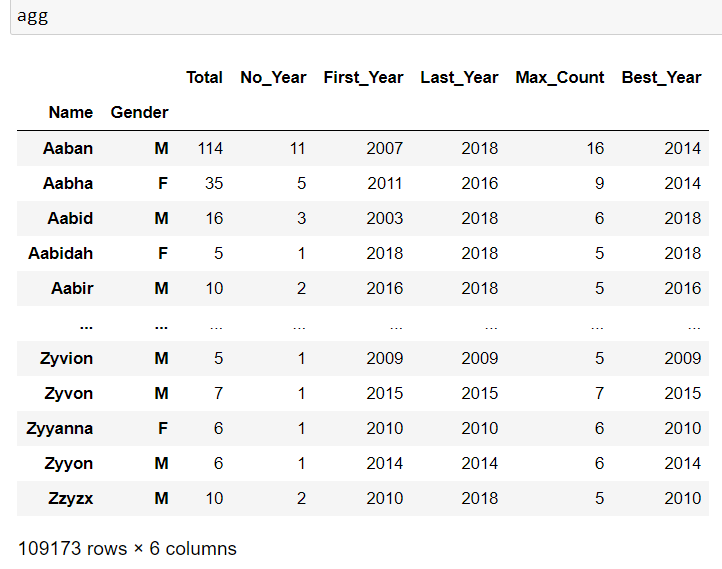

__How to interpret agg (and the first observation Aaban, M):__<br>
- There are in total 114 Male Babies with the name Aaban (Total)<br>
- The combination/entry (Aaban, M) can be found in 11 different years (No_Year)<br>
- The combination/entry (Aaban, M) appeared in the year 2007 for the first time (First_Year)<br>
- The last appearance was in the year 2018 (Last_Year)<br>
- In the most popular year, (Aaban, M) appeared 16 times (Max_Count)
- The most popular year for (Aaban, M) (Best_Year)

In [18]:
df.groupby(["Name", "Gender"], observed=True).Count.sum().reset_index(level = -1)

,Gender,Count
Name,,
Aaban,M,114
Aabha,F,35
Aabid,M,16
Aabidah,F,5
Aabir,M,10
...,...,...
Zyvion,M,5
Zyvon,M,7
Zyyanna,F,6


In [19]:
agg = df.groupby(["Name", "Gender"], observed=True).agg(Total=("Count", "sum"), Numb_Years=("Count", "count"), First_Y=("Year", "min"), Last_Y=("Year", "max"), 
                                         Max_Count=("Count", "max"))
agg

,,Total,Numb_Years,First_Y,Last_Y,Max_Count
Name,Gender,,,,,
Aaban,M,114,11,2007,2018,16
Aabha,F,35,5,2011,2016,9
Aabid,M,16,3,2003,2018,6
Aabidah,F,5,1,2018,2018,5
Aabir,M,10,2,2016,2018,5
...,...,...,...,...,...,...
Zyvion,M,5,1,2009,2009,5
Zyvon,M,7,1,2015,2015,7
Zyyanna,F,6,1,2010,2010,6


In [20]:
def best_year(group):
    return group.nlargest(1, "Count").Year

Option 1

In [21]:
# best_y = df.groupby(["Name", "Gender"], observed=True).apply(best_year, include_groups=False)

In [22]:
#best_y.droplevel(-1)

In [23]:
# agg["Best_Y"] = best_y.droplevel(-1)
# agg

Option 2

In [24]:
best_y = df.sort_values(by="Count", ascending=False).groupby(["Name", "Gender"], observed=True).head(1).drop("Count", axis=1)

In [25]:
best_y = best_y.sort_values(["Name", "Gender"]).set_index(["Name", "Gender"]).Year
best_y

Name     Gender
Aaban    M         2014
Aabha    F         2014
Aabid    M         2018
Aabidah  F         2018
Aabir    M         2018
                   ... 
Zyvion   M         2009
Zyvon    M         2015
Zyyanna  F         2010
Zyyon    M         2014
Zzyzx    M         2010
Name: Year, Length: 109173, dtype: int64

8. __Reset__ the Index and create a RangeIndex.

In [26]:
agg["Best_y"] = best_y

In [27]:
agg.reset_index(inplace=True)
agg

,Name,Gender,Total,Numb_Years,First_Y,Last_Y,Max_Count,Best_y
0,Aaban,M,114,11,2007,2018,16,2014
1,Aabha,F,35,5,2011,2016,9,2014
2,Aabid,M,16,3,2003,2018,6,2018
3,Aabidah,F,5,1,2018,2018,5,2018
4,Aabir,M,10,2,2016,2018,5,2018
...,...,...,...,...,...,...,...,...
109168,Zyvion,M,5,1,2009,2009,5,2009
109169,Zyvon,M,7,1,2015,2015,7,2015
109170,Zyyanna,F,6,1,2010,2010,6,2010
109171,Zyyon,M,6,1,2014,2014,6,2014


9. __Filter__ agg for the combination (Mary, F)

In [28]:
agg[(agg.Name == "Mary") & (agg.Gender == "F")]

,Name,Gender,Total,Numb_Years,First_Y,Last_Y,Max_Count,Best_y
68679,Mary,F,4125675,139,1880,2018,73985,1921


## Most Popular Names of all Times

10. __Find__ the __10 most popular__ Male and Female Names of all Times (most popular in terms of total count). See Screenshot with final result below.

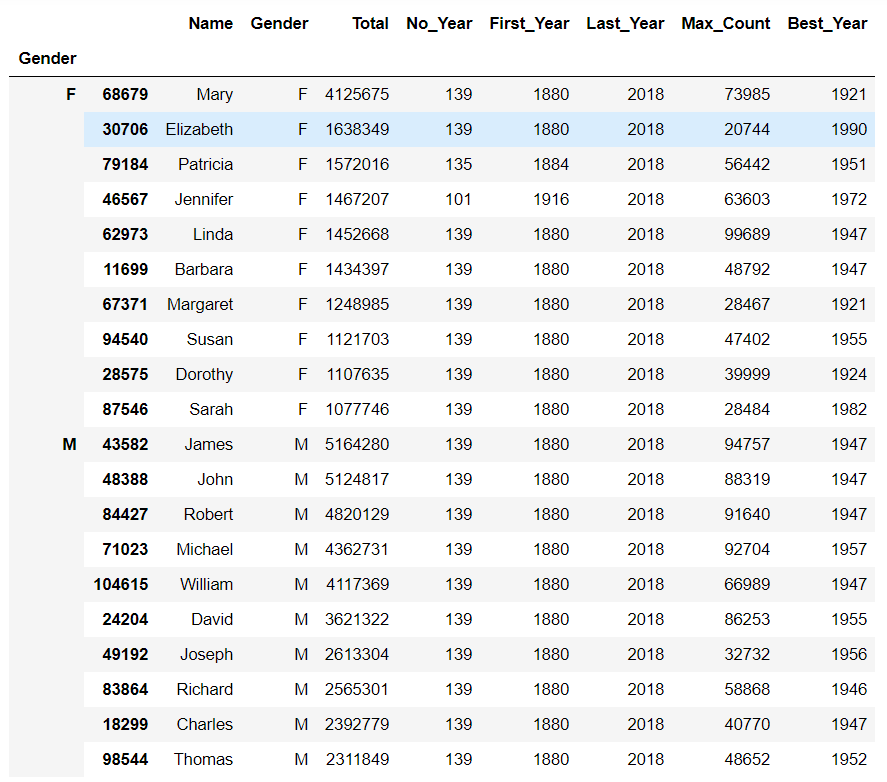

In [29]:
agg.groupby("Gender", observed=True).apply(lambda x: x.nlargest(10, "Total"), include_groups=False)

Name    Total  Numb_Years  First_Y  Last_Y  Max_Count  \
Gender                                                                      
F      68679        Mary  4125675         139     1880    2018      73985   
       30706   Elizabeth  1638349         139     1880    2018      20744   
       79184    Patricia  1572016         135     1884    2018      56442   
       46567    Jennifer  1467207         101     1916    2018      63603   
       62973       Linda  1452668         139     1880    2018      99689   
       11699     Barbara  1434397         139     1880    2018      48792   
       67371    Margaret  1248985         139     1880    2018      28467   
       94540       Susan  1121703         139     1880    2018      47402   
       28575     Dorothy  1107635         139     1880    2018      39999   
       87546       Sarah  1077746         139     1880    2018      28484   
M      43582       James  5164280         139     1880    2018      94757   
       48388        John  5124817         139     1880    2018      88319   
       84427      Robert  4820129         139     1880    2018      91640   
       71023     Michael  4362731         139     1880    2018      92704   
       104615    William  4117369         139     1880    2018      66989   
       24204       David  3621322         139     1880    2018      86253   
       49192      Joseph  2613304         139     1880    2018      32732   
       83864     Richard  2565301         139     1880    2018      58868   
       18299     Charles  2392779         139     1880    2018      40770   
       98544      Thomas  2311849         139     1880    2018      48652   

               Best_y  
Gender                 
F      68679     1921  
       30706     1990  
       79184     1951  
       46567     1972  
       62973     1947  
       11699     1947  
       67371     1921  
       94540     1955  
       28575     1924  
       87546     1982  
M      43582     1947  
       48388     1947  
       84427     1947  
       71023     1957  
       104615    1947  
       24204     1955  
       49192     1956  
       83864     1946  
       18299     1947  
       98544     1952

In [30]:
all_time = agg.groupby("Gender", observed=True).apply(lambda x: x.nlargest(10, "Total"), include_groups=False).reset_index(drop=False)
all_time

,Gender,level_1,Name,Total,Numb_Years,First_Y,Last_Y,Max_Count,Best_y
0,F,68679,Mary,4125675,139,1880,2018,73985,1921
1,F,30706,Elizabeth,1638349,139,1880,2018,20744,1990
2,F,79184,Patricia,1572016,135,1884,2018,56442,1951
3,F,46567,Jennifer,1467207,101,1916,2018,63603,1972
4,F,62973,Linda,1452668,139,1880,2018,99689,1947
5,F,11699,Barbara,1434397,139,1880,2018,48792,1947
6,F,67371,Margaret,1248985,139,1880,2018,28467,1921
7,F,94540,Susan,1121703,139,1880,2018,47402,1955
8,F,28575,Dorothy,1107635,139,1880,2018,39999,1924
9,F,87546,Sarah,1077746,139,1880,2018,28484,1982


## General Trends over time (1880 - 2018)

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

11. __Count__ the total number of __registered Babies per Year__ and visualize. __Create__ the following Plot:

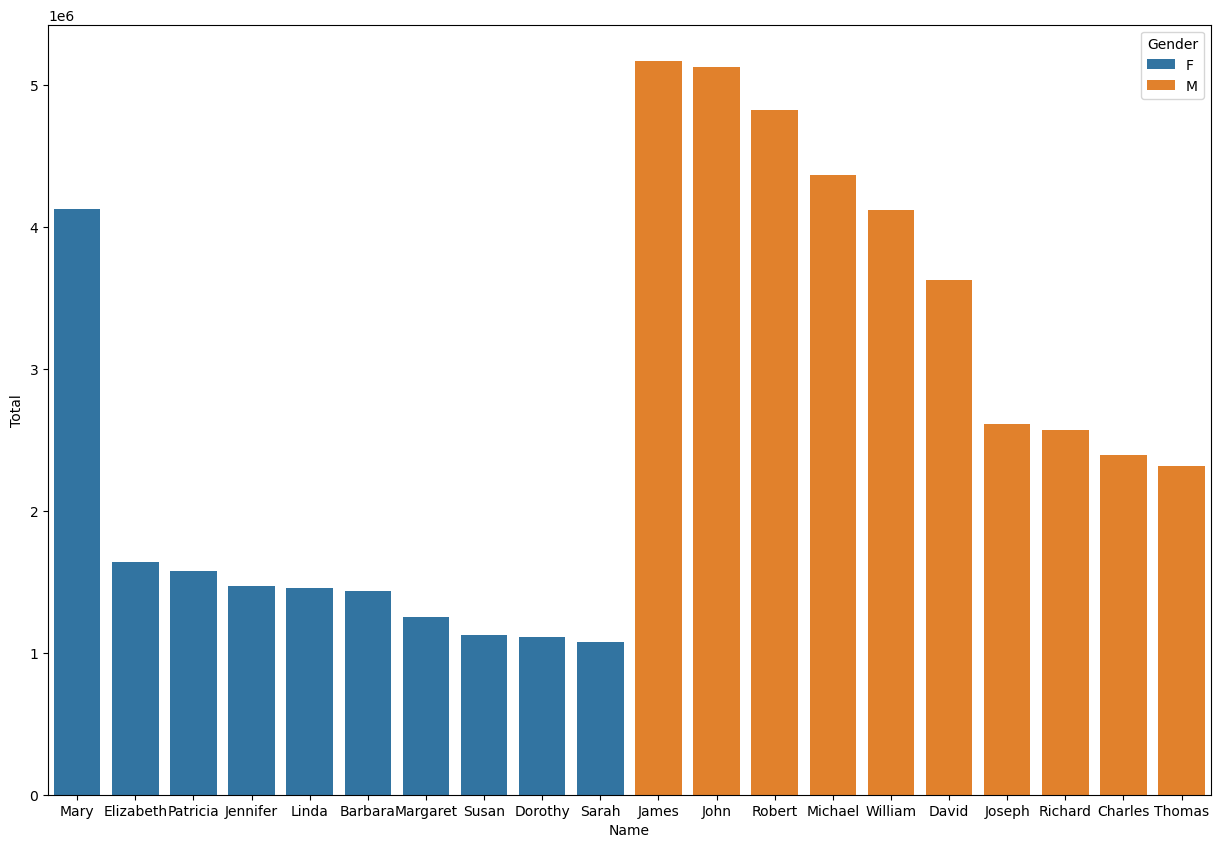

In [32]:
plt.figure(figsize=(15,10))
sns.barplot(x="Name", y="Total", data=all_time, hue="Gender")
plt.show()

In [33]:
pd.options.display.float_format = "{:.0f}".format

In [34]:
babys_per_year = df.groupby("Year").Count.sum()
babys_per_year

Year
1880     201484
1881     192696
1882     221533
1883     216944
1884     243461
         ...   
2014    3698914
2015    3691990
2016    3657797
2017    3561975
2018    3487353
Name: Count, Length: 139, dtype: int64

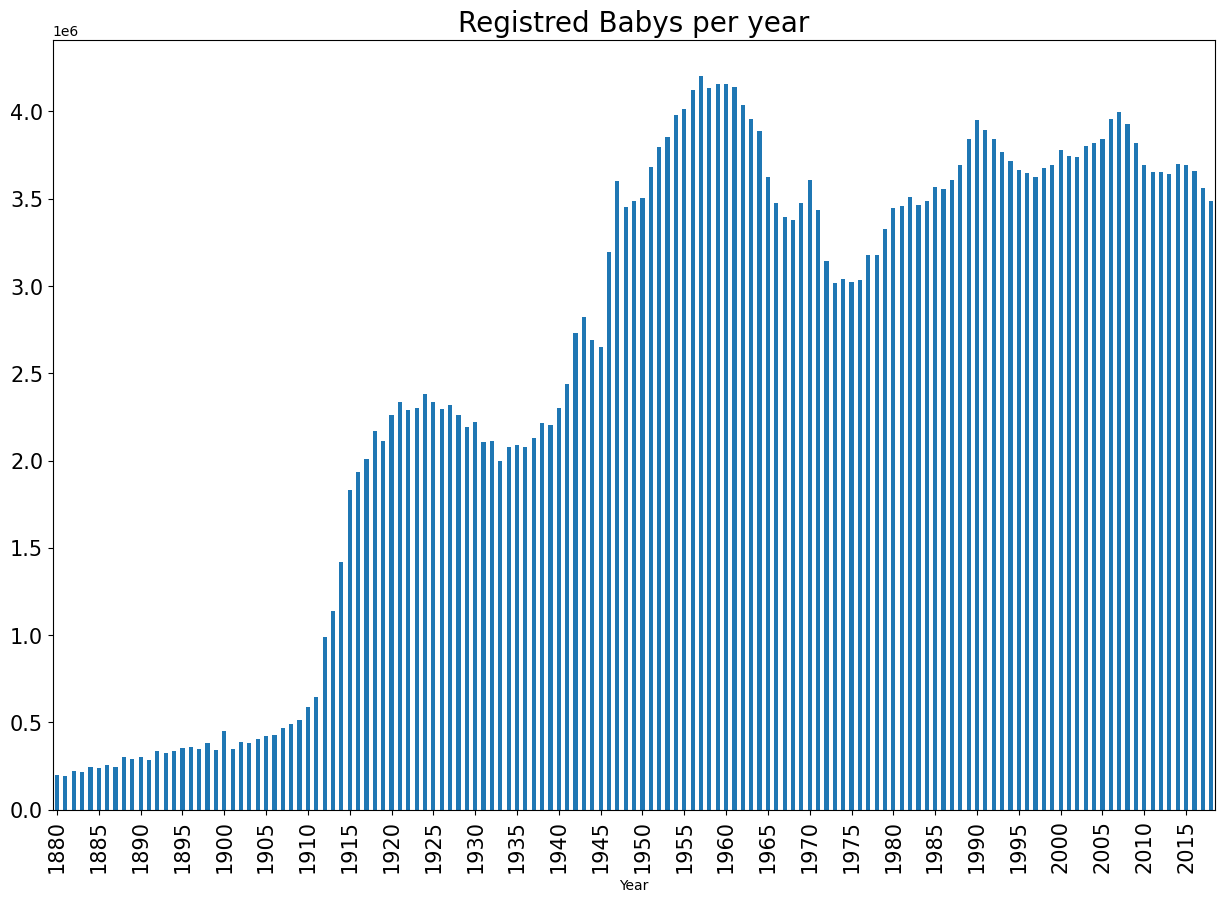

In [35]:
babys_per_year.plot(kind="bar", y="Count", figsize=(15,10), fontsize=15)
plt.xticks(ticks=(range(0, len(babys_per_year), 5)), labels=range(1880, 2019, 5))
plt.title("Registred Babys per year", fontsize=20)
plt.show()

12. __Count__ the total number of __Unique Names per Year__ and visualize. __Create__ the following Plot:

In [36]:
diff_names = df.groupby("Year").Name.count()
diff_names

Year
1880     2000
1881     1935
1882     2127
1883     2084
1884     2297
        ...  
2014    33243
2015    33121
2016    33010
2017    32590
2018    32033
Name: Name, Length: 139, dtype: int64

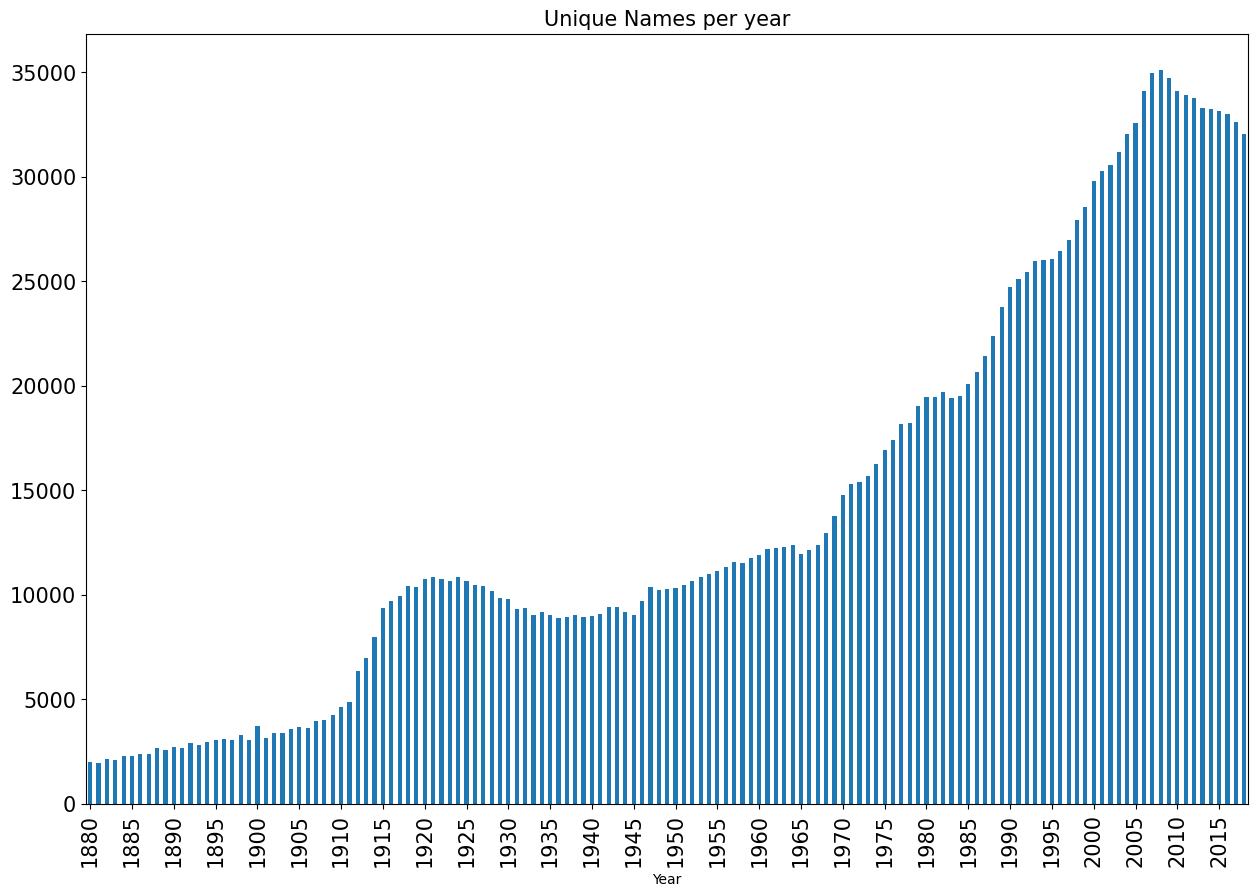

In [37]:
diff_names.plot(kind="bar", y="Count", figsize=(15, 10), fontsize=15)
plt.xticks(ticks=(range(0, len(diff_names), 5)), labels=range(1880, 2019, 5))
plt.title("Unique Names per year", fontsize=15)
plt.show()

## Creating the Features "Popularity" and "Rank"

13. __Add__ the column __"Popularity"__ to df: <br> 

- Popularity in __babies per million__ (example: assume 2,000,000 registered Girl Names in 1950, thereof 100,000 Maries -> Popularity Score in 1950 for (Mary, F) is 100,000 / 2,000,000 * 1,000,000 = 50,000 per million.)  

14. __Add__ the column __"Rank"__ to df: <br> 

- Rank (example: assume Mary is the most popular Girl Name in 1950 -> Rank 1 for (Mary, F) in 1950.

After adding "Popularity" and "Rank", df should look as follows:

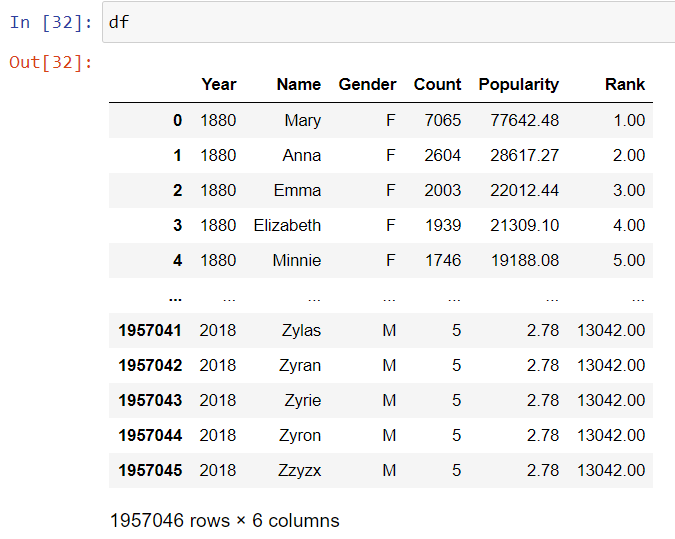

In [38]:
df

,Year,Name,Gender,Count
0,1880,Mary,F,7065
1,1880,Anna,F,2604
2,1880,Emma,F,2003
3,1880,Elizabeth,F,1939
4,1880,Minnie,F,1746
...,...,...,...,...
1957041,2018,Zylas,M,5
1957042,2018,Zyran,M,5
1957043,2018,Zyrie,M,5
1957044,2018,Zyron,M,5


In [39]:
df.groupby(["Year", "Gender"], observed=True).Count.sum()

Year  Gender
1880  F           90994
      M          110490
1881  F           91953
      M          100743
1882  F          107847
                 ...   
2016  M         1891585
2017  F         1719138
      M         1842837
2018  F         1686961
      M         1800392
Name: Count, Length: 278, dtype: int64

To get relative frequency of name Mary per milion: 7065 / 90994 (total amount of F names in 1880) * 1000000 = 77642.48
Count.transform("sum") will give result = 90994

In [40]:
df.Count.div(df.groupby(["Year", "Gender"], observed=True).Count.transform("sum")) * 1000000

0         77642
1         28617
2         22012
3         21309
4         19188
           ... 
1957041       3
1957042       3
1957043       3
1957044       3
1957045       3
Name: Count, Length: 1957046, dtype: float64

In [41]:
df["Popularity"] = df.Count.div(df.groupby(["Year", "Gender"], observed=True).Count.transform("sum")) * 1000000
df

,Year,Name,Gender,Count,Popularity
0,1880,Mary,F,7065,77642
1,1880,Anna,F,2604,28617
2,1880,Emma,F,2003,22012
3,1880,Elizabeth,F,1939,21309
4,1880,Minnie,F,1746,19188
...,...,...,...,...,...
1957041,2018,Zylas,M,5,3
1957042,2018,Zyran,M,5,3
1957043,2018,Zyrie,M,5,3
1957044,2018,Zyron,M,5,3


In [42]:
df["Rank"] = df.groupby(["Year", "Gender"], observed=True).Count.apply(lambda x: x.rank(ascending=False)).reset_index(drop=True)
df

,Year,Name,Gender,Count,Popularity,Rank
0,1880,Mary,F,7065,77642,1
1,1880,Anna,F,2604,28617,2
2,1880,Emma,F,2003,22012,3
3,1880,Elizabeth,F,1939,21309,4
4,1880,Minnie,F,1746,19188,5
...,...,...,...,...,...,...
1957041,2018,Zylas,M,5,3,13042
1957042,2018,Zyran,M,5,3,13042
1957043,2018,Zyrie,M,5,3,13042
1957044,2018,Zyron,M,5,3,13042


In [43]:
df[(df.Year == 2018) & (df.Gender == "M")].head()

,Year,Name,Gender,Count,Popularity,Rank
1943042,2018,Liam,M,19837,11018,1
1943043,2018,Noah,M,18267,10146,2
1943044,2018,William,M,14516,8063,3
1943045,2018,James,M,13525,7512,4
1943046,2018,Oliver,M,13389,7437,5


In [44]:
df[(df.Year == 2018) & (df.Gender == "M")].tail()

,Year,Name,Gender,Count,Popularity,Rank
1957041,2018,Zylas,M,5,3,13042
1957042,2018,Zyran,M,5,3,13042
1957043,2018,Zyrie,M,5,3,13042
1957044,2018,Zyron,M,5,3,13042
1957045,2018,Zzyzx,M,5,3,13042


In [45]:
df[(df.Year == 2018) & (df.Gender == "M")].Popularity.sum()

999999.9999999999

## Visualizing Name Trends over Time

15. __Visualize__ Popularity and Rank over time (see example below).

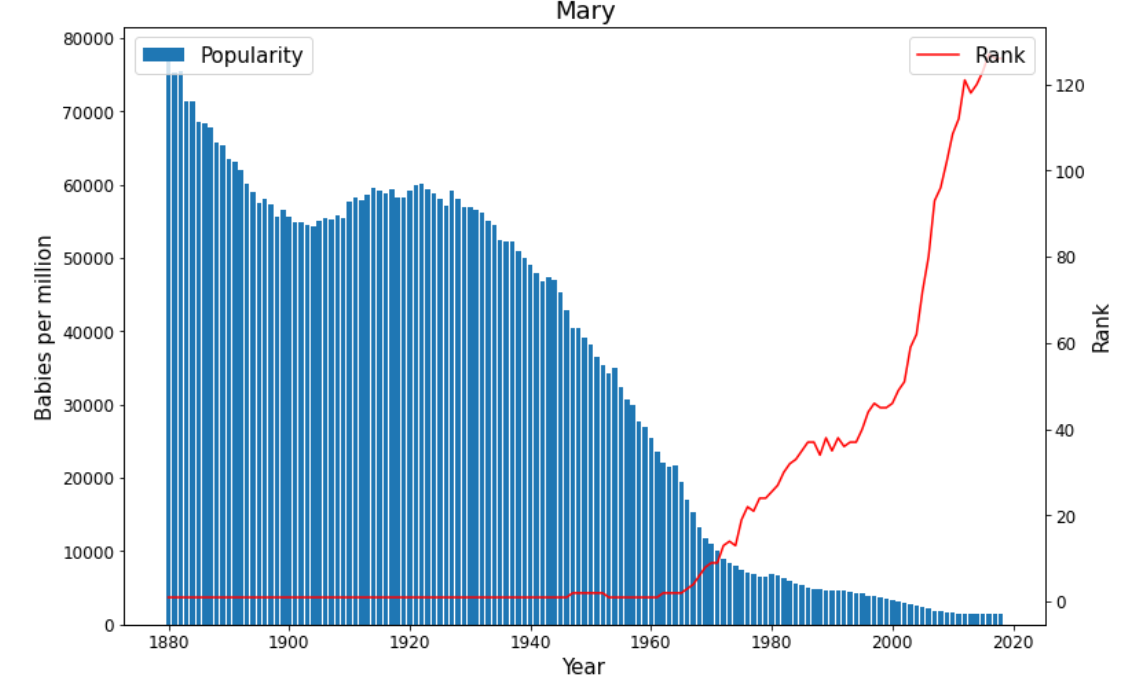

16. __Create__ this plot for all __Evergreen Names__ (see Questions 5. and 6.) (a reusable user-defined function might help)

In [46]:
df

,Year,Name,Gender,Count,Popularity,Rank
0,1880,Mary,F,7065,77642,1
1,1880,Anna,F,2604,28617,2
2,1880,Emma,F,2003,22012,3
3,1880,Elizabeth,F,1939,21309,4
4,1880,Minnie,F,1746,19188,5
...,...,...,...,...,...,...
1957041,2018,Zylas,M,5,3,13042
1957042,2018,Zyran,M,5,3,13042
1957043,2018,Zyrie,M,5,3,13042
1957044,2018,Zyron,M,5,3,13042


In [47]:
mary = df[(df.Name == "Mary") & (df.Gender == "F")]
mary.head()

,Year,Name,Gender,Count,Popularity,Rank
0,1880,Mary,F,7065,77642,1
2000,1881,Mary,F,6919,75245,1
3935,1882,Mary,F,8148,75551,1
6062,1883,Mary,F,8012,71333,1
8146,1884,Mary,F,9217,71439,1


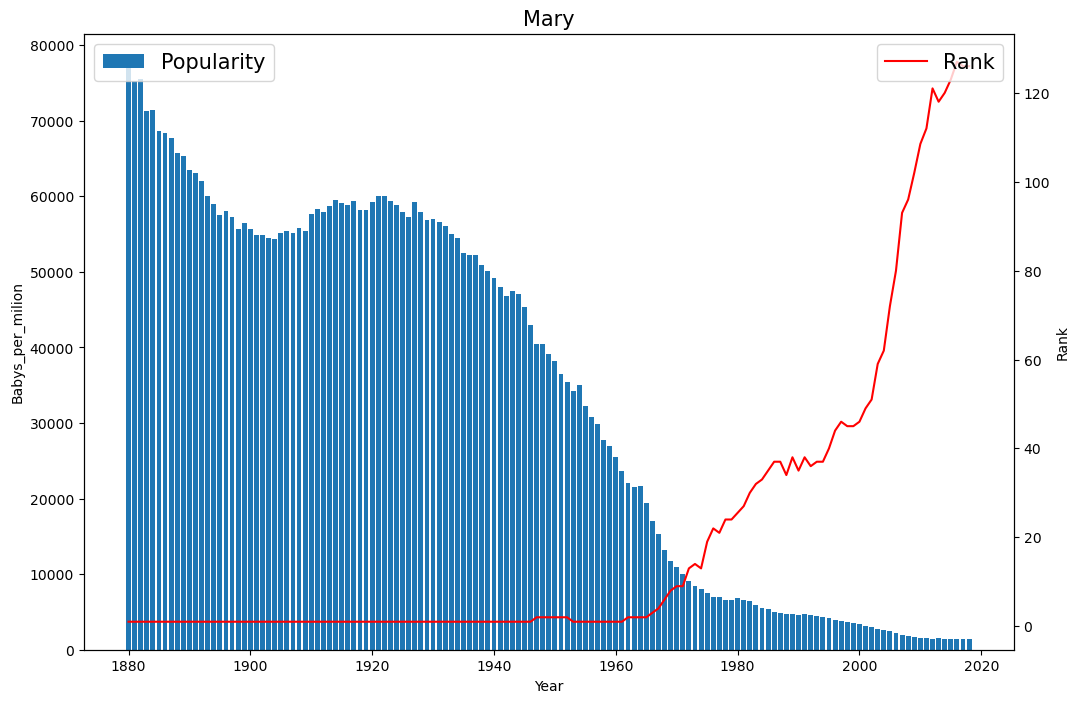

In [48]:
fig, ax1 = plt.subplots(figsize=(12, 8))
ax1.bar(x=mary.Year, height=mary.Popularity, label="Popularity")
ax2 = ax1.twinx()
ax2.plot(mary.Year, mary.Rank, color="red", label="Rank")
ax1.set_xlabel("Year", fontsize=10)
ax1.set_ylabel("Babys_per_milion", fontsize=10)
ax2.set_ylabel("Rank", fontsize=10)
ax1.set_title("Mary", fontsize=15)
ax1.tick_params(labelsize=10)
ax2.tick_params(labelsize=10)
ax1.legend(loc=2, fontsize=15)
ax2.legend(loc=1, fontsize=15)
plt.show()

In [49]:
def plot_name(name, gender, crit="Popularity"):
    data = df.loc[(df.Name == name) & (df.Gender == gender), ["Name", "Gender", "Year", "Rank", crit]]
    data = data.set_index("Year")
    
    fig, ax1 = plt.subplots(figsize=(12, 8))
    ax1.bar(x=data.index, height=data[crit], label=crit)
    ax2 = ax1.twinx()
    ax2.plot(data.index, data.Rank, color="red", label="Rank")
    ax1.set_xlabel("Year", fontsize=10)
    ax1.set_ylabel(crit, fontsize=10)
    ax2.set_ylabel("Rank", fontsize=10)
    ax1.set_title(name, fontsize=15)
    ax1.tick_params(labelsize=10)
    ax2.tick_params(labelsize=10)
    ax1.legend(loc=2, fontsize=15)
    ax2.legend(loc=1, fontsize=15)
    plt.show()

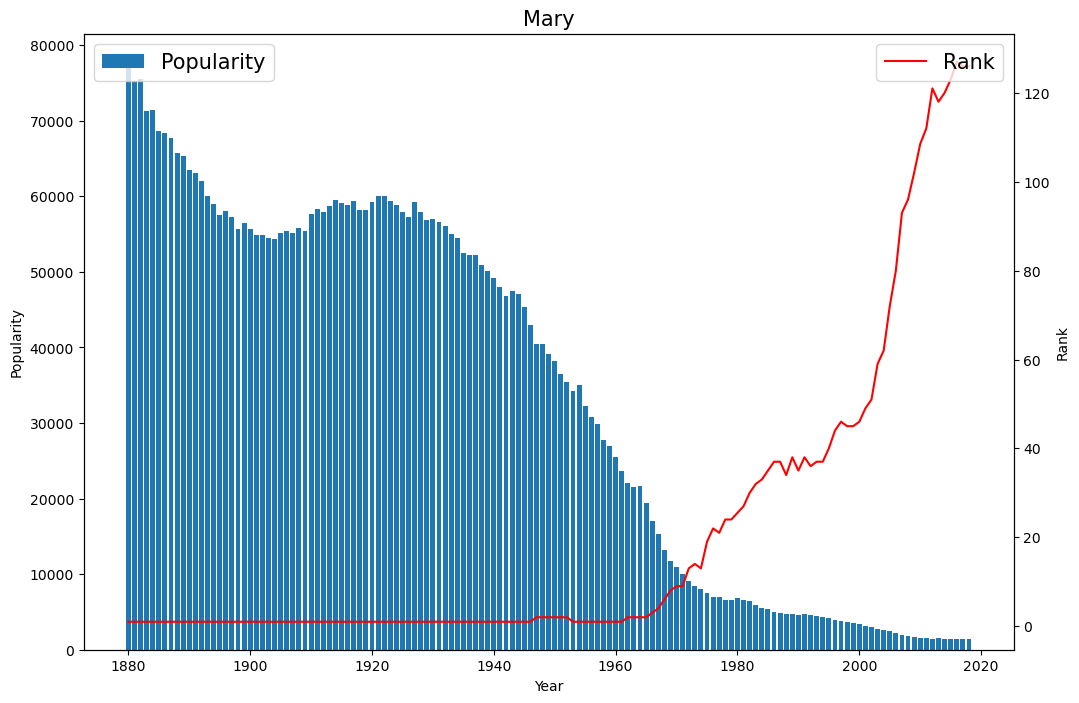

In [50]:
plot_name("Mary", "F")

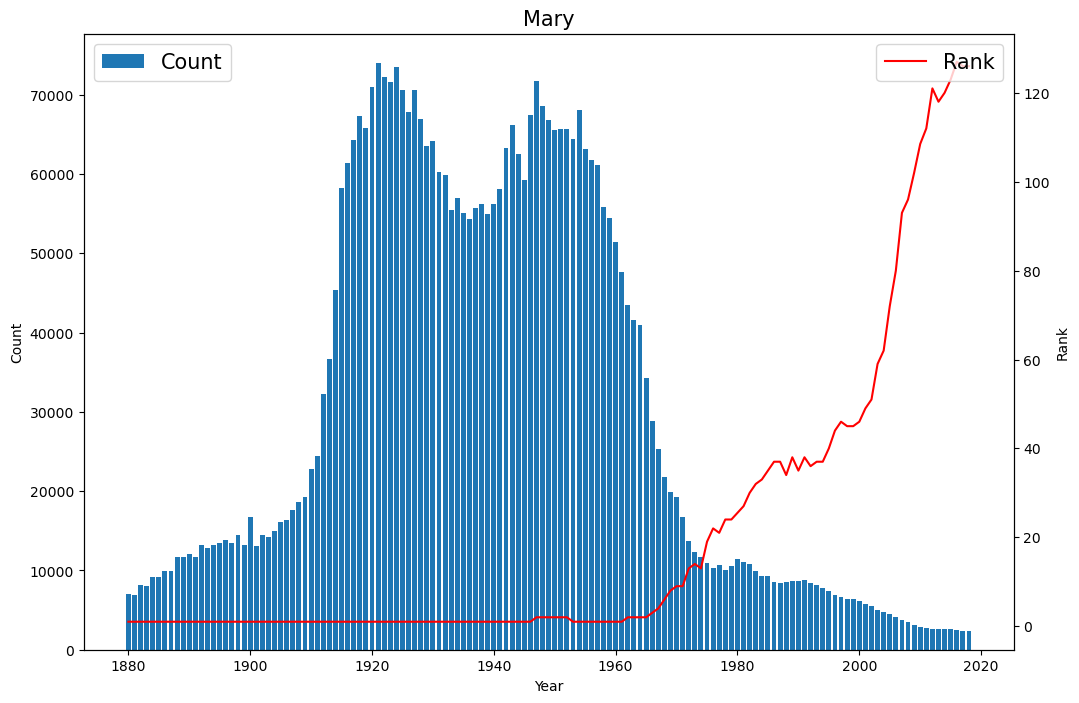

In [51]:
plot_name("Mary", "F", crit="Count")

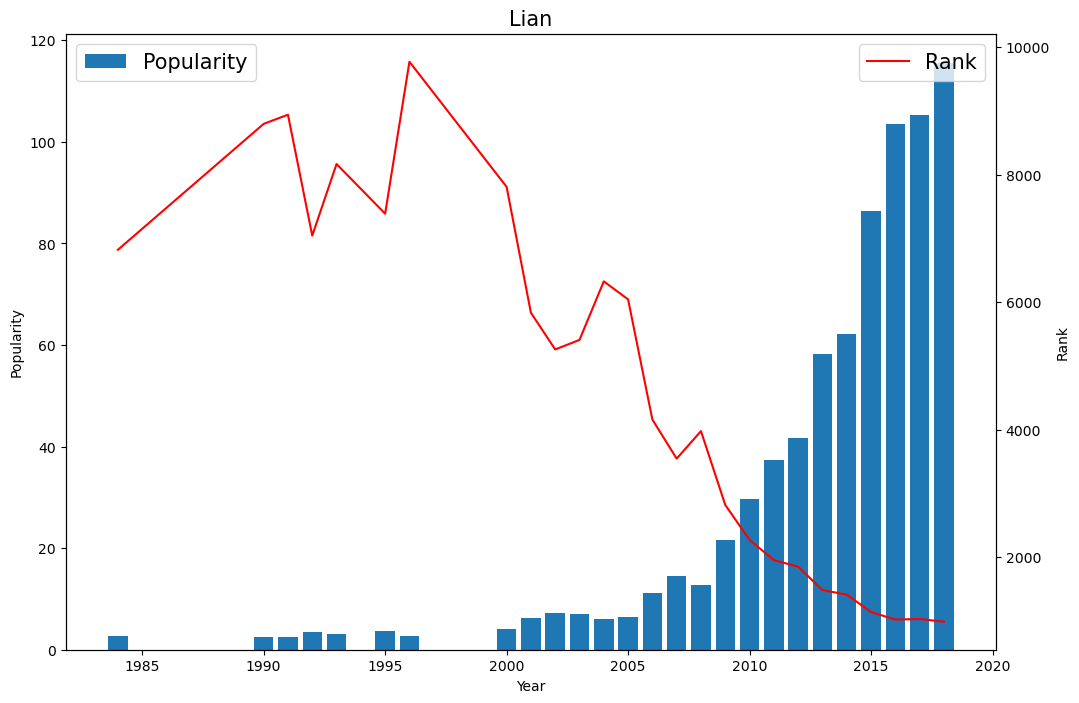

In [52]:
plot_name("Lian", "M", crit="Popularity")

In [53]:
m_evergiven

,Name,Count_2018,Count_1880
0,William,14516,9532
1,James,13525,5927
2,Henry,10649,2444


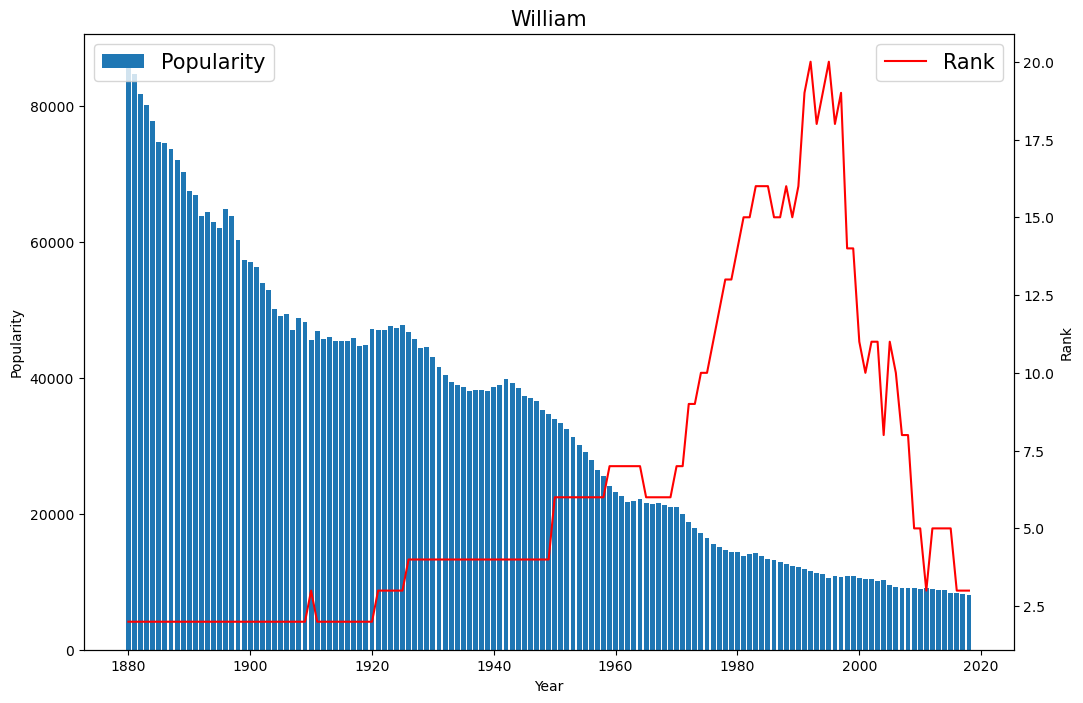

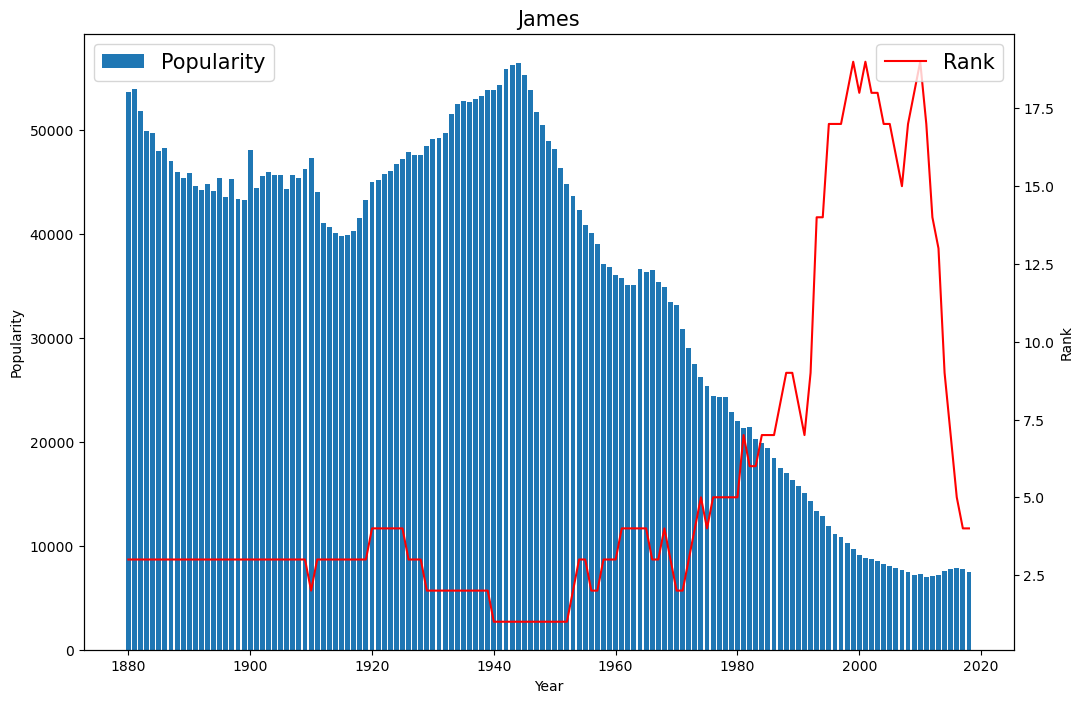

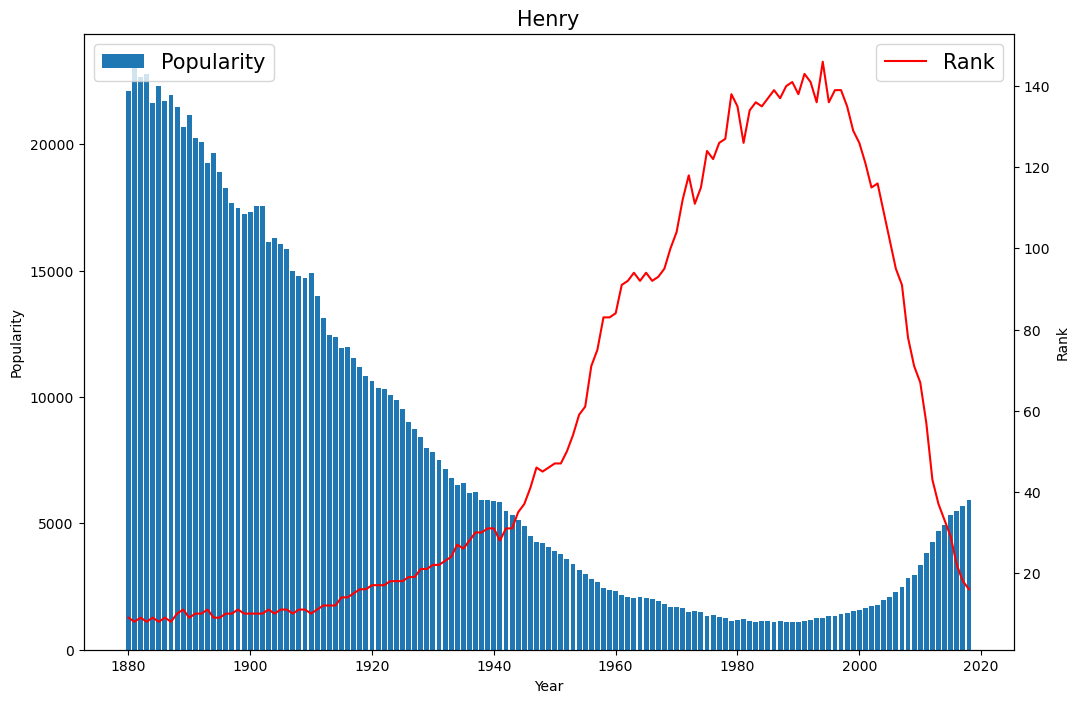

In [54]:
for name in m_evergiven.Name:
    plot_name(name, "M", crit="Popularity")

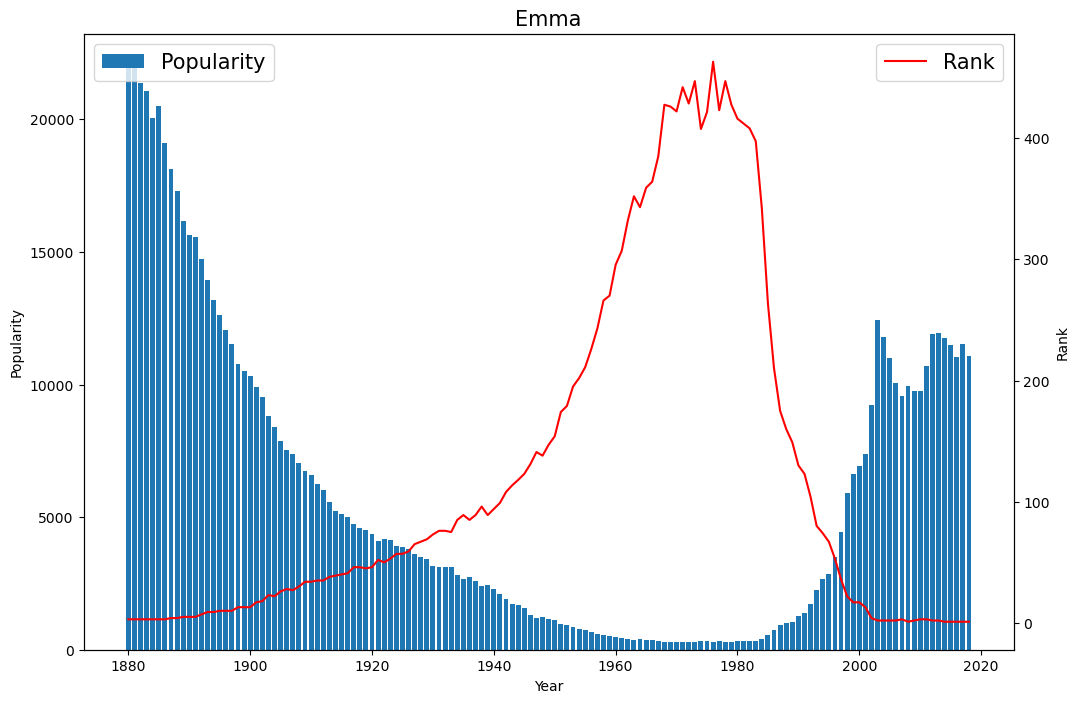

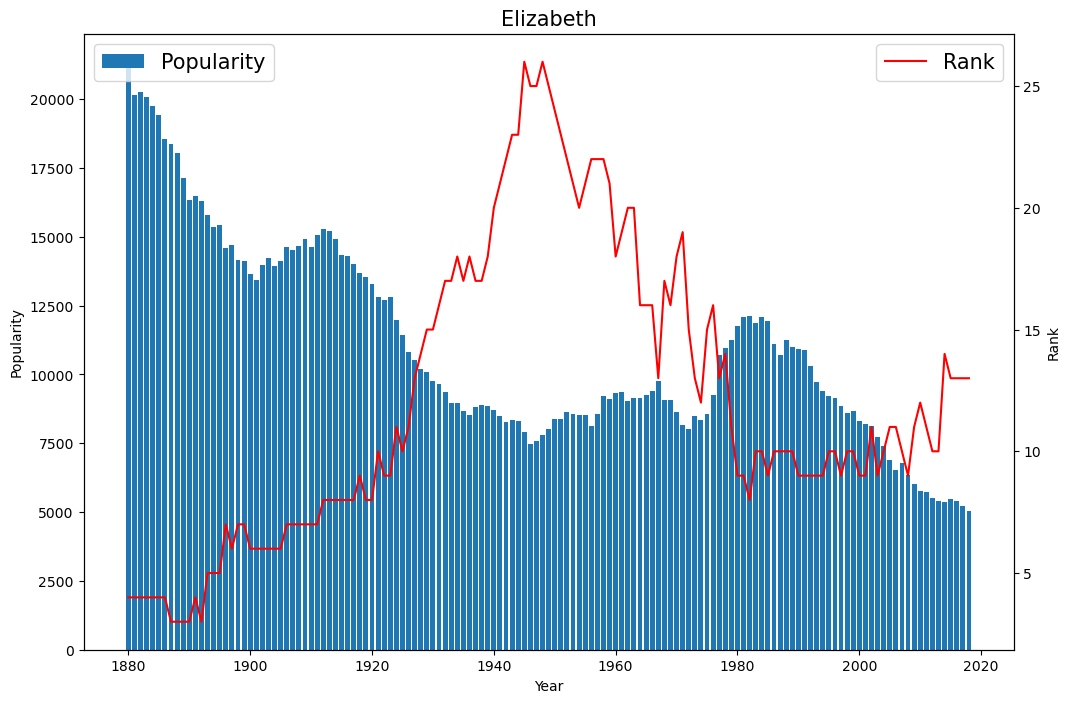

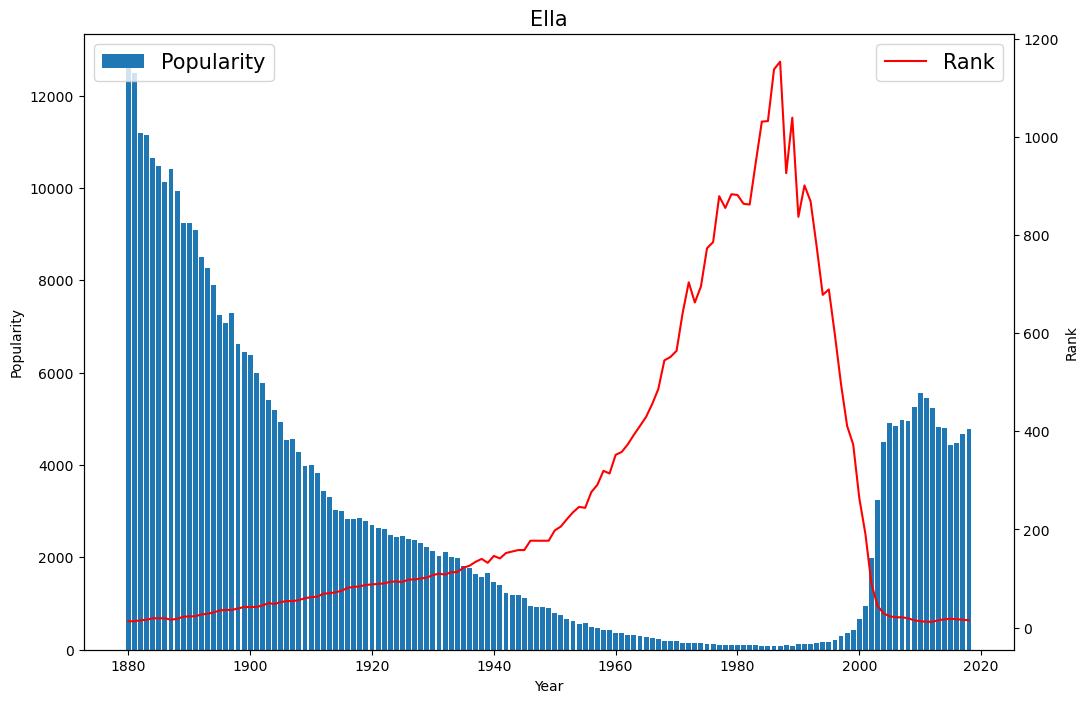

In [55]:
for name in f_evergiven.Name:
    plot_name(name, "F", crit="Popularity")

# Why does a Name´s Popularity suddenly change? (Part 1)

17. __Add__ the additional columns __"Pop_lag1"__ (Popularity one year ago) and __"Pop_diff"__ (change in popularity from previous year to this year) to df.  

18. __Create__ df2 starting with the __year 1900__ (from 1900 till today).

19. __Filter__ df2 and find the __20 largest values__ in "Pop_diff" (get complete rows).

20. __Create__ the popularity/rank plot (see 15. and 16.) for the Names filtered in 19.

21. __Search__ the Web for the Names __"Linda"__, __"Shirley"__ and __"Jason"__ and __find out__ why the popularity suddenly changed/spiked.

In [56]:
df.loc[(df.Name == "Mary") & (df.Gender == "F"), "Popularity"]

0         77642
2000      75245
3935      75551
6062      71333
8146      71439
           ... 
1793168    1477
1826414    1478
1859539    1420
1892548    1397
1925138    1379
Name: Popularity, Length: 139, dtype: float64

Shift method allowed to get Popularity value fm previose year 1879

In [57]:
df["Pop_lag1"] = df.groupby([df.Name, df.Gender], observed=True).Popularity.shift()
df

,Year,Name,Gender,Count,Popularity,Rank,Pop_lag1
0,1880,Mary,F,7065,77642,1,NaN
1,1880,Anna,F,2604,28617,2,NaN
2,1880,Emma,F,2003,22012,3,NaN
3,1880,Elizabeth,F,1939,21309,4,NaN
4,1880,Minnie,F,1746,19188,5,NaN
...,...,...,...,...,...,...,...
1957041,2018,Zylas,M,5,3,13042,4
1957042,2018,Zyran,M,5,3,13042,3
1957043,2018,Zyrie,M,5,3,13042,3
1957044,2018,Zyron,M,5,3,13042,8


Segrigate data for Unisex names, like Ashanti 

In [58]:
df[df.Name == "Ashanti"] 

,Year,Name,Gender,Count,Popularity,Rank,Pop_lag1
700697,1970,Ashanti,F,14,8,4142,NaN
708512,1970,Ashanti,M,14,8,2565,NaN
714597,1971,Ashanti,F,21,13,3216,8
724746,1971,Ashanti,M,8,5,3809,8
729787,1972,Ashanti,F,21,14,3117,13
...,...,...,...,...,...,...,...
1827752,2015,Ashanti,F,157,88,1464,103
1857597,2015,Ashanti,M,5,3,13046,3
1860841,2016,Ashanti,F,161,91,1432,88
1893982,2017,Ashanti,F,140,81,1562,91


Replace missing values for Ashanti data with 0

In [59]:
df.loc[(df.Year > 1880 ) & (df.Pop_lag1.isna()), "Pop_lag1"] = 0
df[df.Name == "Ashanti"]

,Year,Name,Gender,Count,Popularity,Rank,Pop_lag1
700697,1970,Ashanti,F,14,8,4142,0
708512,1970,Ashanti,M,14,8,2565,0
714597,1971,Ashanti,F,21,13,3216,8
724746,1971,Ashanti,M,8,5,3809,8
729787,1972,Ashanti,F,21,14,3117,13
...,...,...,...,...,...,...,...
1827752,2015,Ashanti,F,157,88,1464,103
1857597,2015,Ashanti,M,5,3,13046,3
1860841,2016,Ashanti,F,161,91,1432,88
1893982,2017,Ashanti,F,140,81,1562,91


In [60]:
df["Pop_Diff"] = df.Popularity - df.Pop_lag1 

In [61]:
df[(df.Name == "Mary") & (df.Gender == "F")]

,Year,Name,Gender,Count,Popularity,Rank,Pop_lag1,Pop_Diff
0,1880,Mary,F,7065,77642,1,NaN,NaN
2000,1881,Mary,F,6919,75245,1,77642,-2398
3935,1882,Mary,F,8148,75551,1,75245,307
6062,1883,Mary,F,8012,71333,1,75551,-4219
8146,1884,Mary,F,9217,71439,1,71333,107
...,...,...,...,...,...,...,...,...
1793168,2014,Mary,F,2632,1477,120,1514,-37
1826414,2015,Mary,F,2631,1478,123,1477,1
1859539,2016,Mary,F,2508,1420,127,1478,-58
1892548,2017,Mary,F,2402,1397,126,1420,-23


In [62]:
df[df.Name == "Ashanti"]

,Year,Name,Gender,Count,Popularity,Rank,Pop_lag1,Pop_Diff
700697,1970,Ashanti,F,14,8,4142,0,8
708512,1970,Ashanti,M,14,8,2565,0,8
714597,1971,Ashanti,F,21,13,3216,8,5
724746,1971,Ashanti,M,8,5,3809,8,-3
729787,1972,Ashanti,F,21,14,3117,13,1
...,...,...,...,...,...,...,...,...
1827752,2015,Ashanti,F,157,88,1464,103,-15
1857597,2015,Ashanti,M,5,3,13046,3,-0
1860841,2016,Ashanti,F,161,91,1432,88,3
1893982,2017,Ashanti,F,140,81,1562,91,-10


In [63]:
df2 = df[df.Year >= 1900].copy()
df2

,Year,Name,Gender,Count,Popularity,Rank,Pop_lag1,Pop_Diff
52265,1900,Mary,F,16706,55724,1,56527,-802
52266,1900,Helen,F,6343,21158,2,21663,-506
52267,1900,Anna,F,6114,20394,3,21951,-1557
52268,1900,Margaret,F,5304,17692,4,18234,-542
52269,1900,Ruth,F,4765,15894,5,16788,-894
...,...,...,...,...,...,...,...,...
1957041,2018,Zylas,M,5,3,13042,4,-1
1957042,2018,Zyran,M,5,3,13042,3,-0
1957043,2018,Zyrie,M,5,3,13042,3,0
1957044,2018,Zyron,M,5,3,13042,8,-5


In [64]:
df2.nlargest(20, "Pop_Diff")

,Year,Name,Gender,Count,Popularity,Rank,Pop_lag1,Pop_Diff
431066,1947,Linda,F,99689,56236,1,33547,22689
321479,1935,Shirley,F,42358,40398,2,21874,18524
922468,1983,Ashley,F,33293,19930,4,8775,11156
711426,1971,Jennifer,F,56783,34134,1,26403,7730
726721,1972,Jennifer,F,63603,41813,1,34134,7680
312301,1934,Shirley,F,22840,21874,4,14203,7671
645417,1966,Michelle,F,27151,16047,4,9186,6861
751941,1973,Jason,M,46683,29940,3,23081,6859
844807,1979,Amanda,F,31928,19890,3,13394,6496
696647,1970,Jennifer,F,46157,26403,1,19978,6425


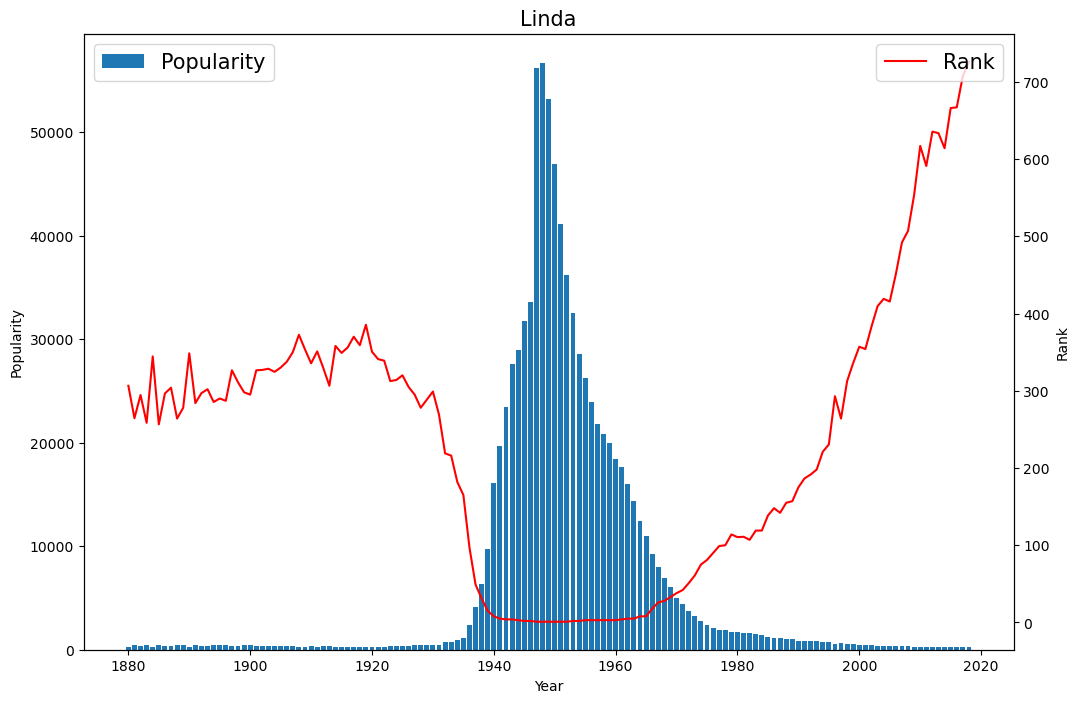

In [65]:
plot_name("Linda", "F")

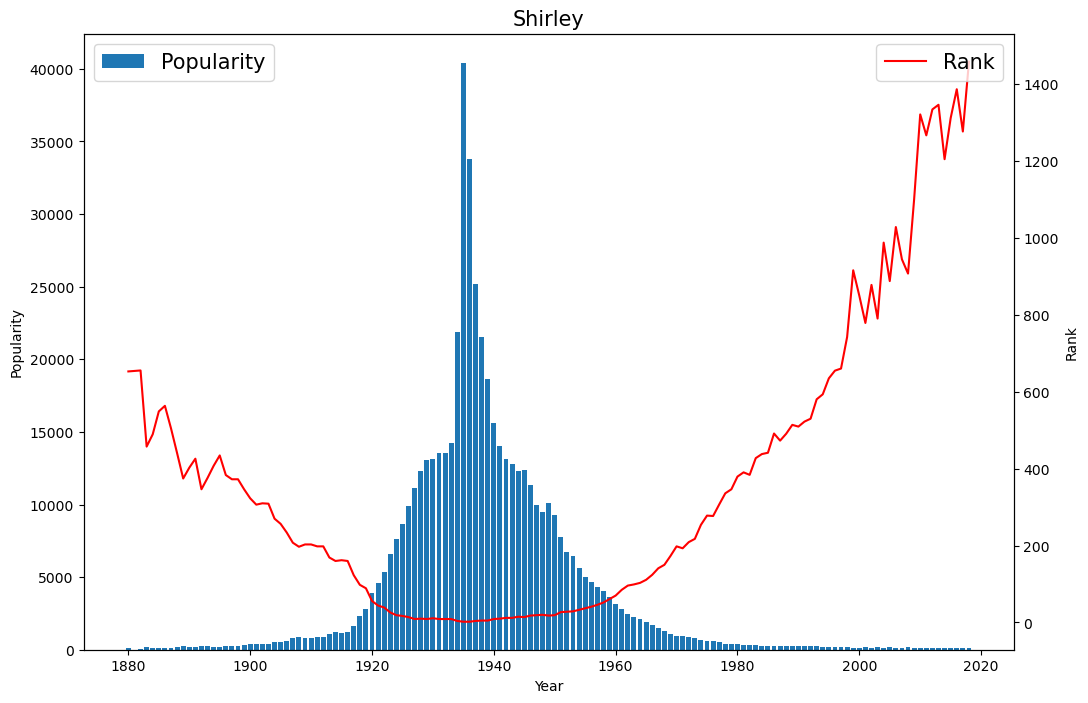

In [66]:
plot_name("Shirley", "F")

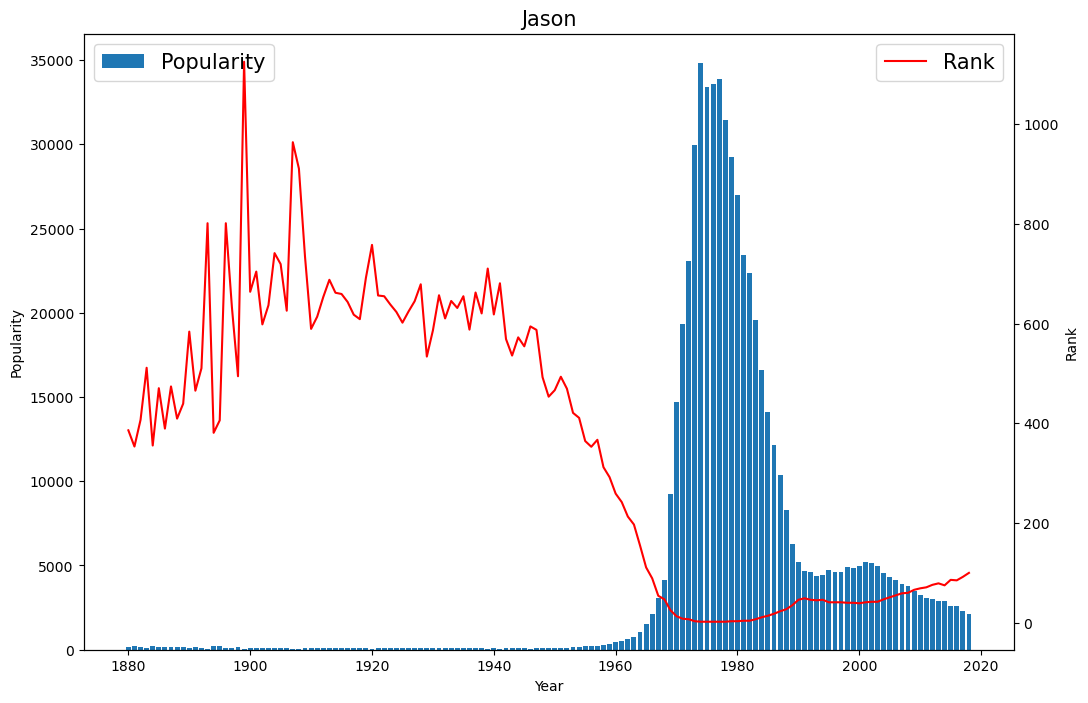

In [67]:
plot_name("Jason", "M")

In [68]:
df.nsmallest(20, "Pop_Diff")

,Year,Name,Gender,Count,Popularity,Rank,Pop_lag1,Pop_Diff
339412,1937,Shirley,F,26816,25204,4,33798,-8593
330516,1936,Shirley,F,35161,33798,2,40398,-6601
461947,1950,Linda,F,80431,46952,1,53199,-6248
472250,1951,Linda,F,73978,41079,1,46952,-5872
961380,1985,Jennifer,F,42651,24789,3,30032,-5243
482712,1952,Linda,F,67082,36174,1,41079,-4905
696648,1970,Lisa,F,38963,22288,2,26692,-4404
51103,1899,Dewey,M,499,4698,39,9088,-4390
437173,1947,Richard,M,58521,31990,5,36252,-4263
537623,1957,Deborah,F,40071,19601,6,23827,-4226


## Why does a Name´s Popularity suddenly change? (Part 2)

_No additional assignments on this. Watch the video for some more examples._

In [69]:
df[(df.Pop_lag1 < 5)].nlargest(20, "Pop_Diff")

,Year,Name,Gender,Count,Popularity,Rank,Pop_lag1,Pop_Diff
758040,1974,Nakia,F,1134,773,226,5,768
808621,1977,Kizzy,F,1116,728,223,0,728
1060680,1989,Christop,M,1082,541,242,0,541
768358,1974,Nakia,M,612,389,302,0,389
820064,1977,Levar,M,523,318,342,0,318
48244,1898,Hobson,M,38,310,311,0,310
645832,1966,Tabatha,F,500,296,419,3,293
1553888,2007,Jaslene,F,501,261,600,3,258
1223510,1996,Moesha,F,426,243,548,0,243
1070200,1990,Isamar,F,446,235,534,0,235


In [70]:
df[df.Name == "Nakia"]

,Year,Name,Gender,Count,Popularity,Rank,Pop_lag1,Pop_Diff
749309,1973,Nakia,F,7,5,7049,0,5
758040,1974,Nakia,F,1134,773,226,5,768
768358,1974,Nakia,M,612,389,302,0,389
774314,1975,Nakia,F,972,667,251,773,-106
785009,1975,Nakia,M,514,329,338,389,-60
...,...,...,...,...,...,...,...,...
1834158,2015,Nakia,F,15,8,7792,11,-2
1854673,2015,Nakia,M,8,4,9138,5,-1
1865530,2016,Nakia,F,21,12,6072,8,3
1906059,2017,Nakia,F,7,4,13370,12,-8


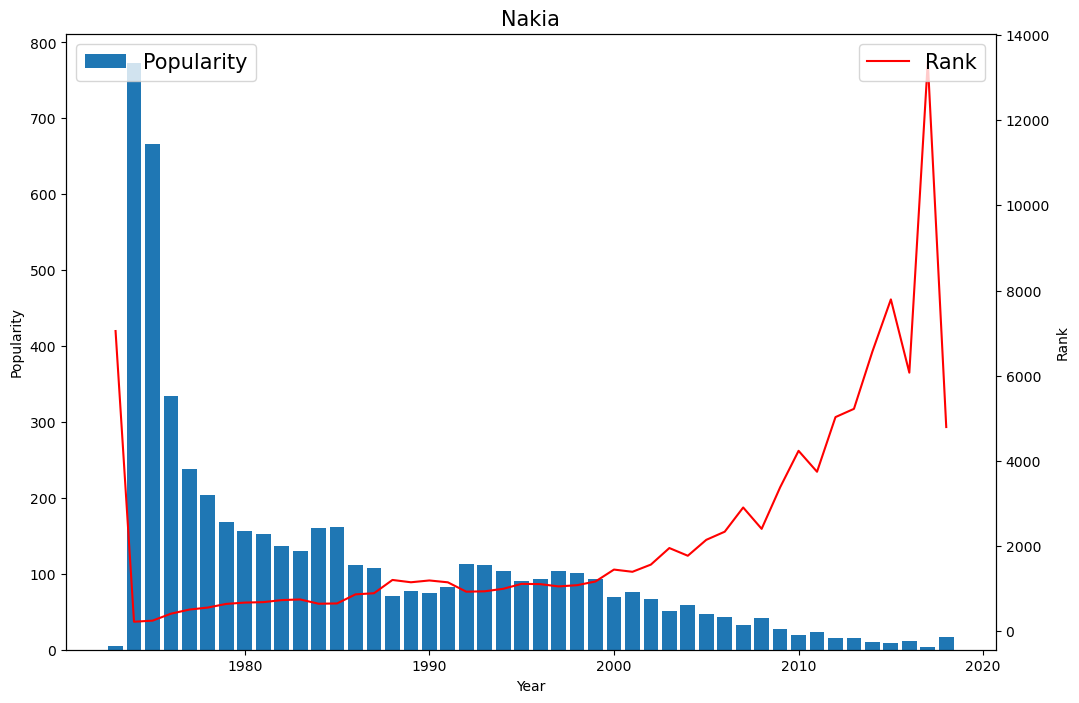

In [71]:
plot_name("Nakia", "F")

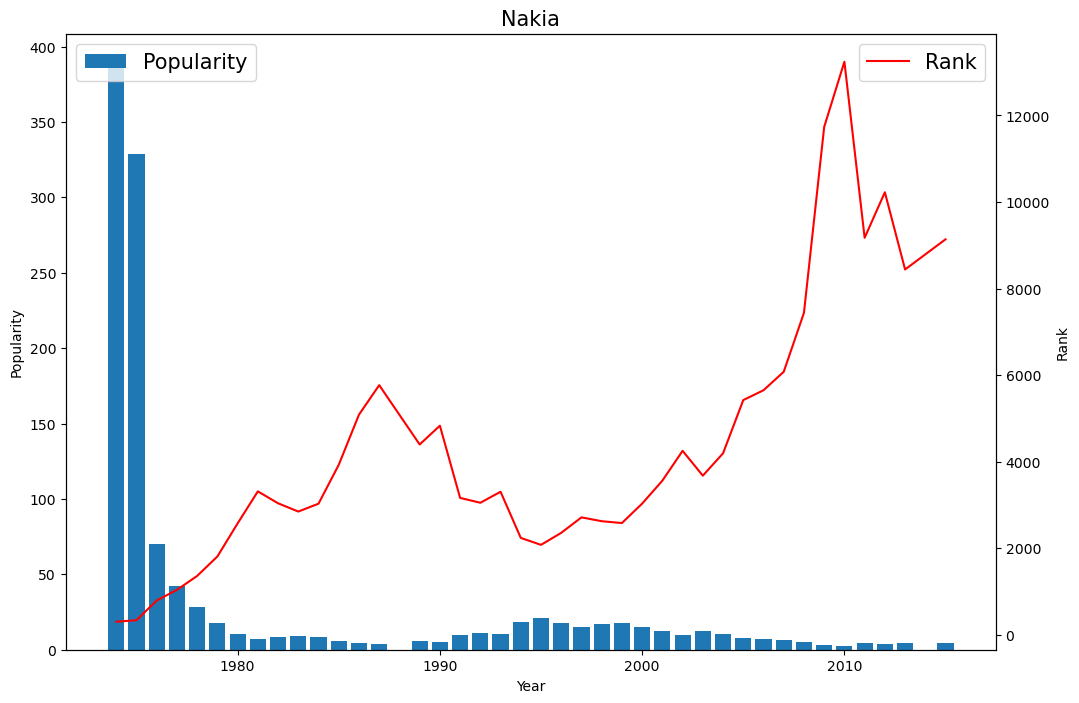

In [72]:
plot_name("Nakia", "M")

## Persistant vs. Spike-Fade Names

_No additional assignments on this. Watch the video for some more advanced examples._

In [73]:
df2

,Year,Name,Gender,Count,Popularity,Rank,Pop_lag1,Pop_Diff
52265,1900,Mary,F,16706,55724,1,56527,-802
52266,1900,Helen,F,6343,21158,2,21663,-506
52267,1900,Anna,F,6114,20394,3,21951,-1557
52268,1900,Margaret,F,5304,17692,4,18234,-542
52269,1900,Ruth,F,4765,15894,5,16788,-894
...,...,...,...,...,...,...,...,...
1957041,2018,Zylas,M,5,3,13042,4,-1
1957042,2018,Zyran,M,5,3,13042,3,-0
1957043,2018,Zyrie,M,5,3,13042,3,0
1957044,2018,Zyron,M,5,3,13042,8,-5


In [74]:
df2["%change"] = df.Popularity.div(df2.Pop_lag1).sub(1).mul(100)
df2

,Year,Name,Gender,Count,Popularity,Rank,Pop_lag1,Pop_Diff,%change
52265,1900,Mary,F,16706,55724,1,56527,-802,-1
52266,1900,Helen,F,6343,21158,2,21663,-506,-2
52267,1900,Anna,F,6114,20394,3,21951,-1557,-7
52268,1900,Margaret,F,5304,17692,4,18234,-542,-3
52269,1900,Ruth,F,4765,15894,5,16788,-894,-5
...,...,...,...,...,...,...,...,...,...
1957041,2018,Zylas,M,5,3,13042,4,-1,-27
1957042,2018,Zyran,M,5,3,13042,3,-0,-12
1957043,2018,Zyrie,M,5,3,13042,3,0,2
1957044,2018,Zyron,M,5,3,13042,8,-5,-66


In [75]:
df2[df2.Pop_lag1 > 1000].nsmallest(20, "%change")

,Year,Name,Gender,Count,Popularity,Rank,Pop_lag1,Pop_Diff,%change
758121,1974,Katina,F,765,521,307,1697,-1175,-69
1119924,1992,Iesha,F,581,315,432,1011,-696,-69
1423744,2003,Ashanti,F,962,527,325,1640,-1113,-68
515370,1955,Marian,F,1499,767,208,2067,-1300,-63
175401,1920,Woodrow,M,774,727,182,1845,-1117,-61
1145180,1993,Hillary,F,1064,588,261,1367,-779,-57
1249716,1997,Shania,F,861,495,330,1047,-552,-53
54563,1900,Dewey,M,345,2293,75,4698,-2406,-51
275072,1930,Jeannine,F,593,527,258,1060,-533,-50
981635,1986,Sheena,F,1573,917,173,1780,-863,-48


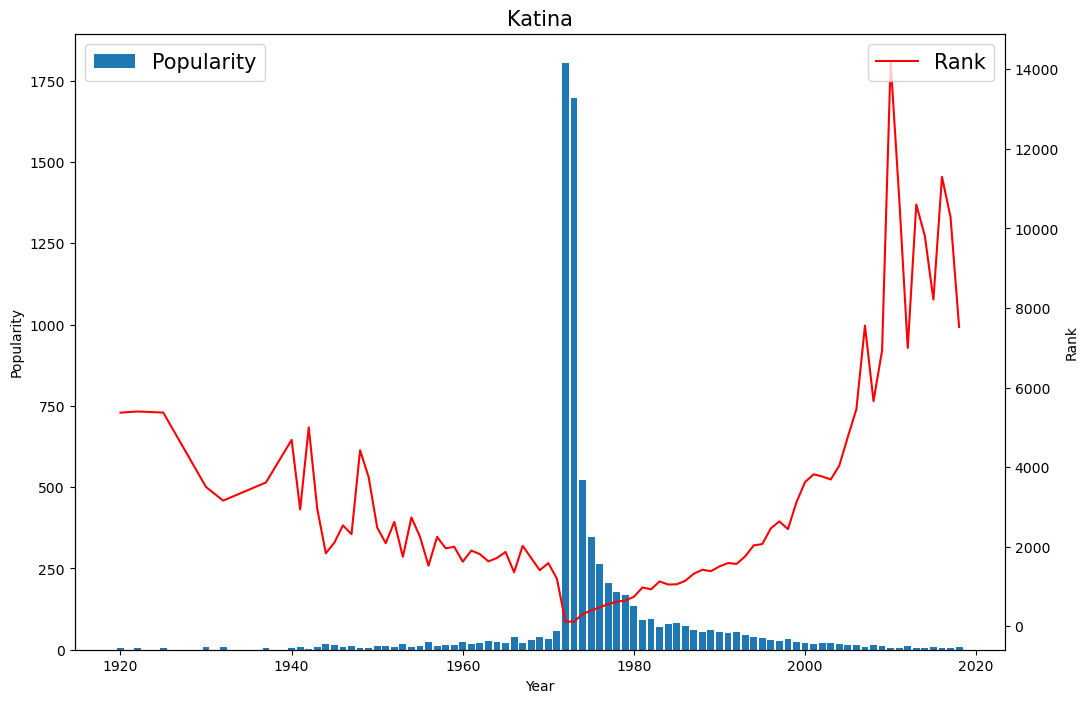

In [76]:
plot_name("Katina", "F")

## Most Popular Unisex Names

22. __Find__ the most popular __Unisex Names__ of all times. (Unisex names are names given to Boys and Girls).  

In [77]:
agg

,Name,Gender,Total,Numb_Years,First_Y,Last_Y,Max_Count,Best_y
0,Aaban,M,114,11,2007,2018,16,2014
1,Aabha,F,35,5,2011,2016,9,2014
2,Aabid,M,16,3,2003,2018,6,2018
3,Aabidah,F,5,1,2018,2018,5,2018
4,Aabir,M,10,2,2016,2018,5,2018
...,...,...,...,...,...,...,...,...
109168,Zyvion,M,5,1,2009,2009,5,2009
109169,Zyvon,M,7,1,2015,2015,7,2015
109170,Zyyanna,F,6,1,2010,2010,6,2010
109171,Zyyon,M,6,1,2014,2014,6,2014


In [78]:
agg["Spike_Score"] = agg.Max_Count.div(agg.Total).mul(100)
agg

,Name,Gender,Total,Numb_Years,First_Y,Last_Y,Max_Count,Best_y,Spike_Score
0,Aaban,M,114,11,2007,2018,16,2014,14
1,Aabha,F,35,5,2011,2016,9,2014,26
2,Aabid,M,16,3,2003,2018,6,2018,38
3,Aabidah,F,5,1,2018,2018,5,2018,100
4,Aabir,M,10,2,2016,2018,5,2018,50
...,...,...,...,...,...,...,...,...,...
109168,Zyvion,M,5,1,2009,2009,5,2009,100
109169,Zyvon,M,7,1,2015,2015,7,2015,100
109170,Zyyanna,F,6,1,2010,2010,6,2010,100
109171,Zyyon,M,6,1,2014,2014,6,2014,100


In [79]:
agg.sort_values(by="Spike_Score", ascending=True).head()

,Name,Gender,Total,Numb_Years,First_Y,Last_Y,Max_Count,Best_y,Spike_Score
49192,Joseph,M,2613304,139,1880,2018,32732,1956,1
30706,Elizabeth,F,1638349,139,1880,2018,20744,1990,1
85133,Rosa,F,174125,139,1880,2018,2230,1925,1
69242,Maurice,M,134504,139,1880,2018,1743,1921,1
25419,Delia,F,36276,139,1880,2018,491,1957,1


In [80]:
persons = agg.sort_values(by="Spike_Score", ascending=True).head()
persons

,Name,Gender,Total,Numb_Years,First_Y,Last_Y,Max_Count,Best_y,Spike_Score
49192,Joseph,M,2613304,139,1880,2018,32732,1956,1
30706,Elizabeth,F,1638349,139,1880,2018,20744,1990,1
85133,Rosa,F,174125,139,1880,2018,2230,1925,1
69242,Maurice,M,134504,139,1880,2018,1743,1921,1
25419,Delia,F,36276,139,1880,2018,491,1957,1


In [81]:
l = list(zip(persons.Name, persons.Gender))
l

[('Joseph', 'M'),
 ('Elizabeth', 'F'),
 ('Rosa', 'F'),
 ('Maurice', 'M'),
 ('Delia', 'F')]

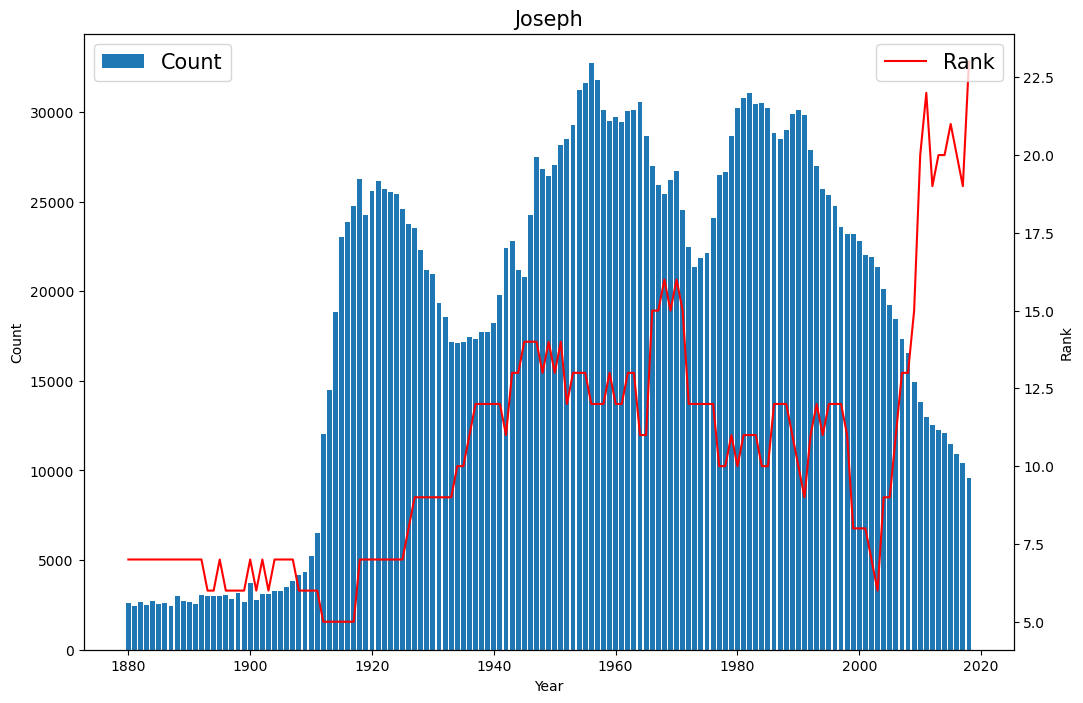

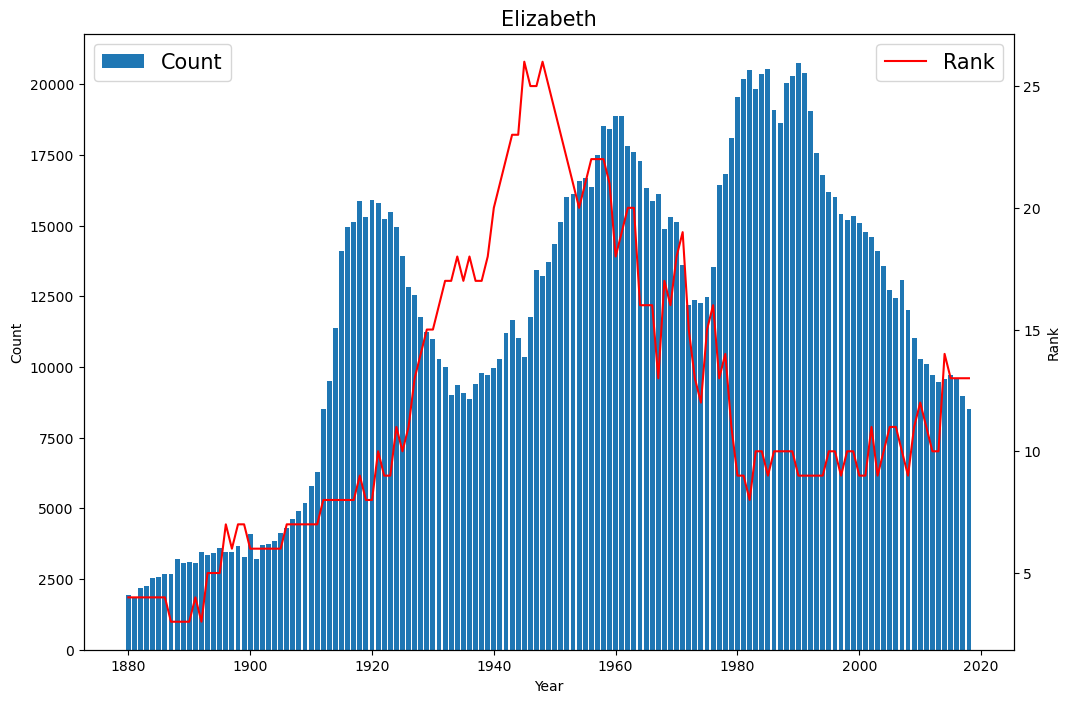

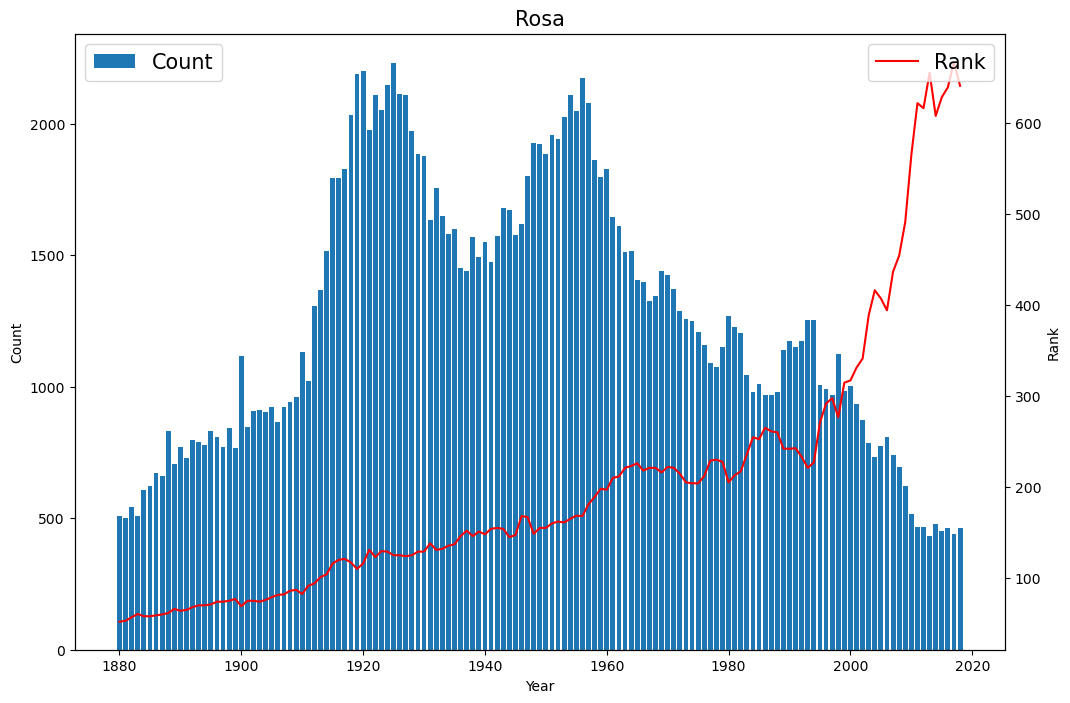

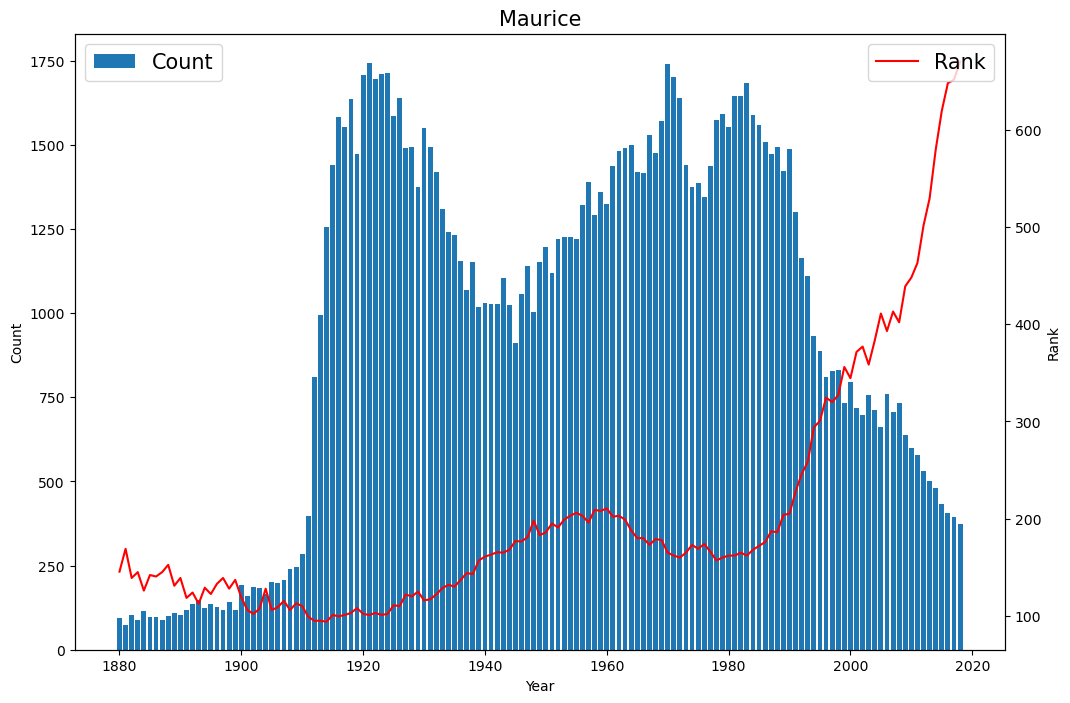

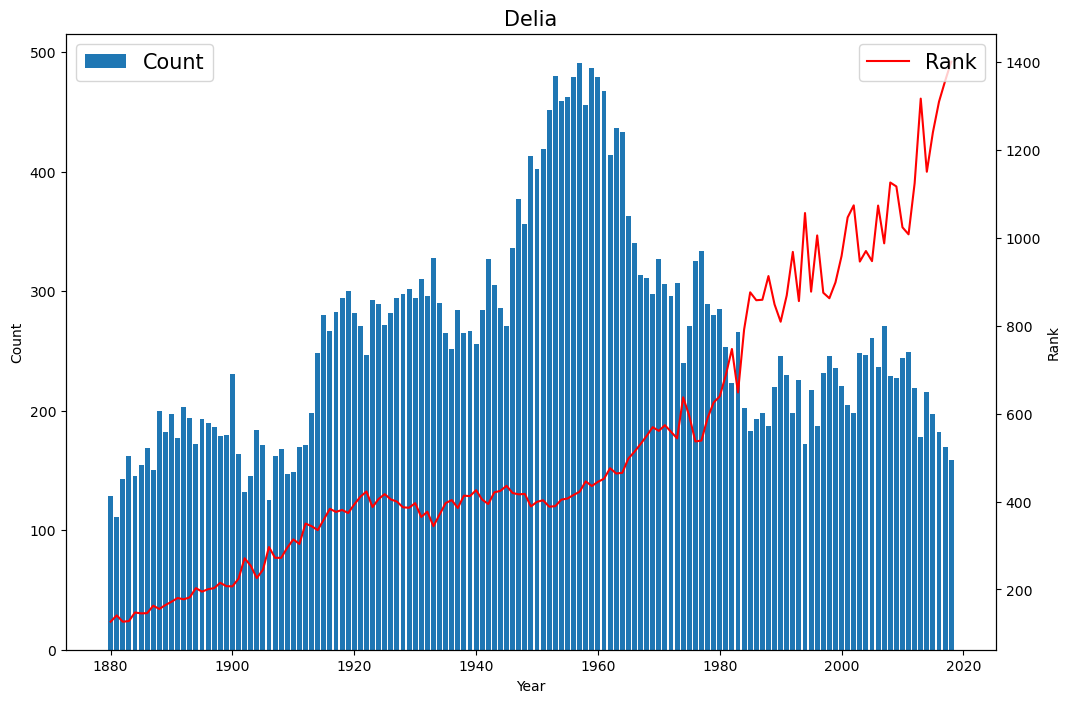

In [82]:
for n in l:
    plot_name(name=n[0], gender=n[1], crit="Count")

In [83]:
spike = agg[(agg.Total > 1000) & (agg.Numb_Years > 10)].sort_values(by="Spike_Score", ascending=False).head()
spike

,Name,Gender,Total,Numb_Years,First_Y,Last_Y,Max_Count,Best_y,Spike_Score
57027,Kizzy,F,2325,30,1977,2016,1116,1977,48
77282,Oaklyn,F,1381,11,2006,2018,627,2018,45
25998,Deneen,F,3603,52,1947,2007,1604,1964,45
72223,Moesha,F,1067,14,1996,2014,426,1996,40
67328,Mareli,F,1038,22,1995,2018,411,2008,40


In [84]:
l2 = list(zip(spike.Name, spike.Gender))
l2

[('Kizzy', 'F'),
 ('Oaklyn', 'F'),
 ('Deneen', 'F'),
 ('Moesha', 'F'),
 ('Mareli', 'F')]

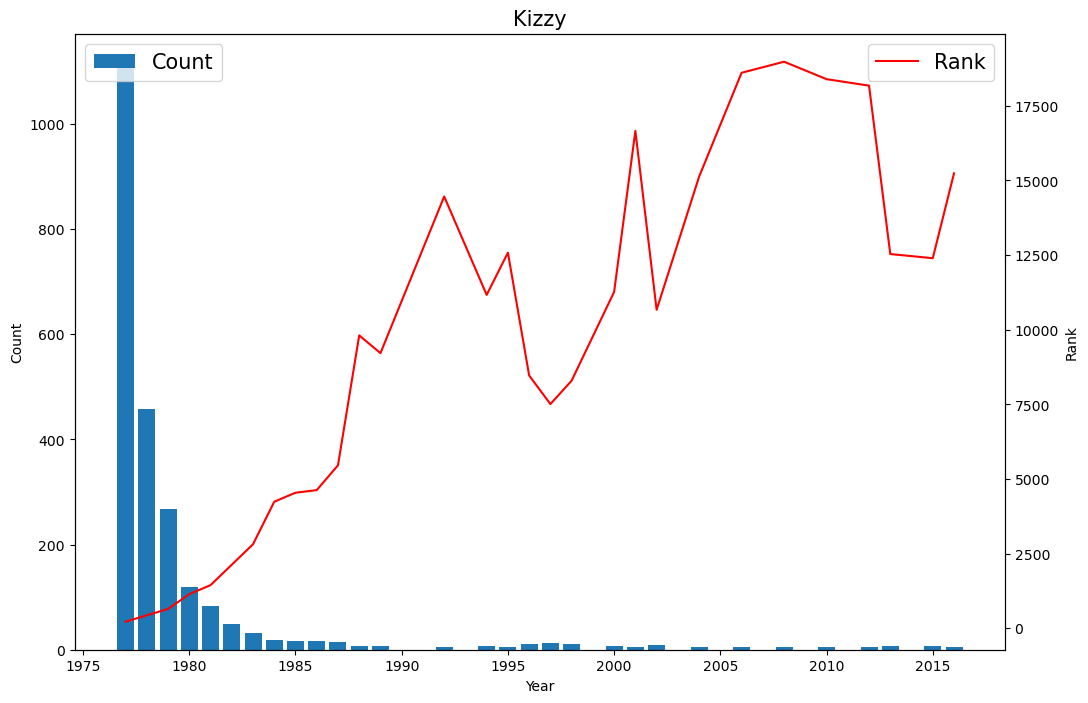

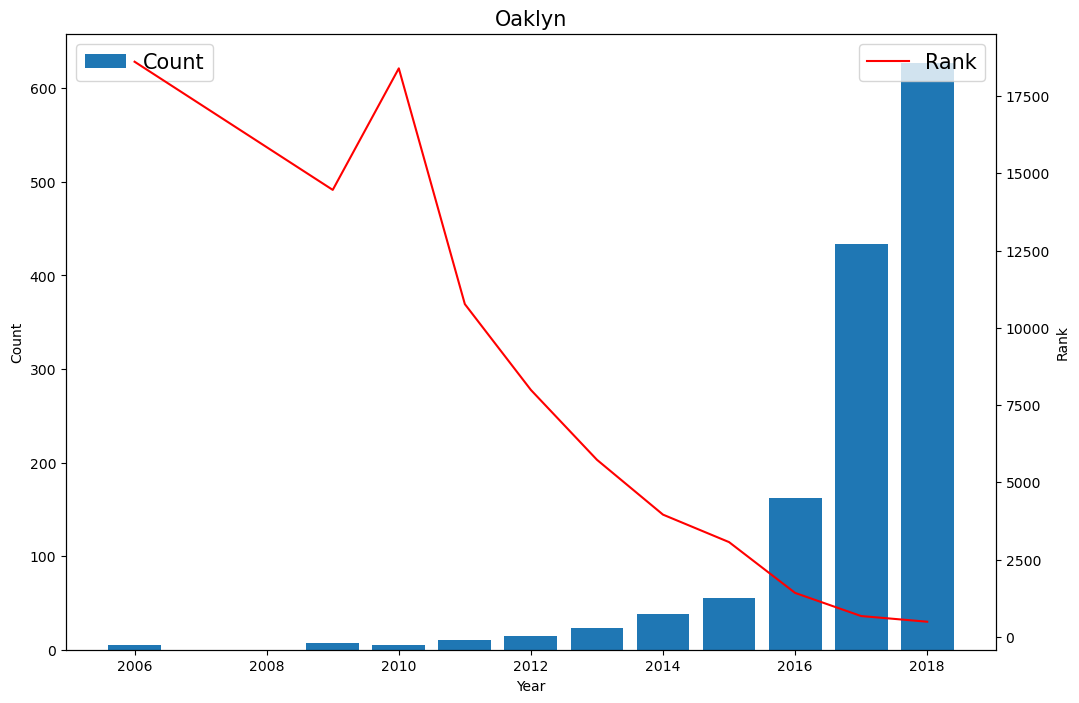

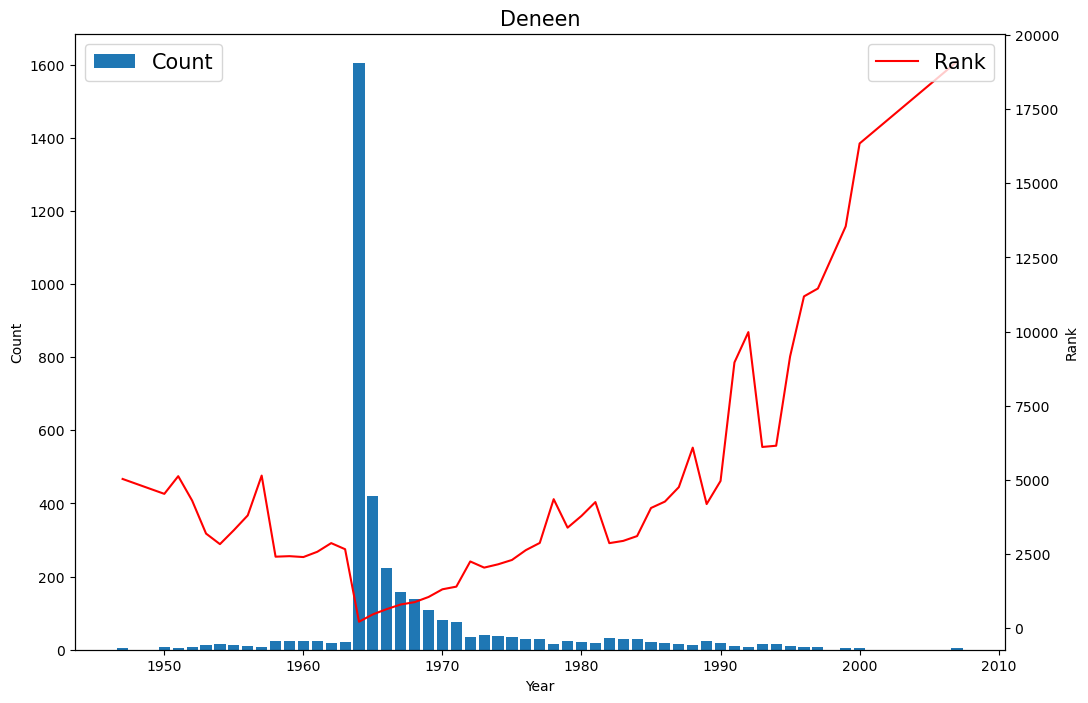

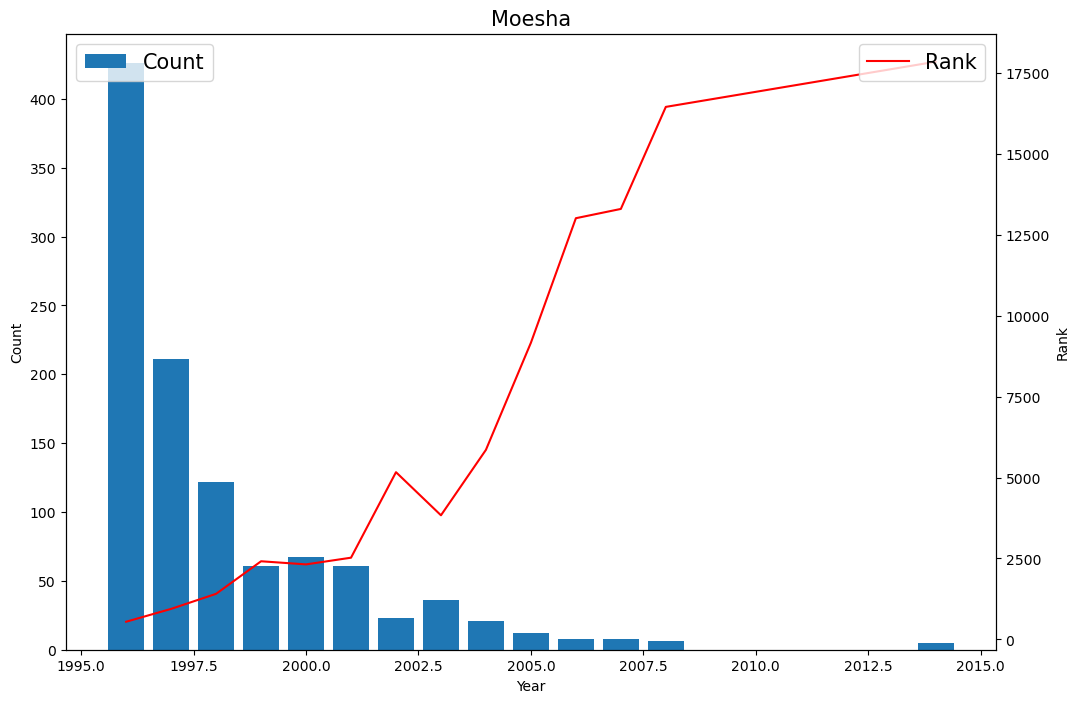

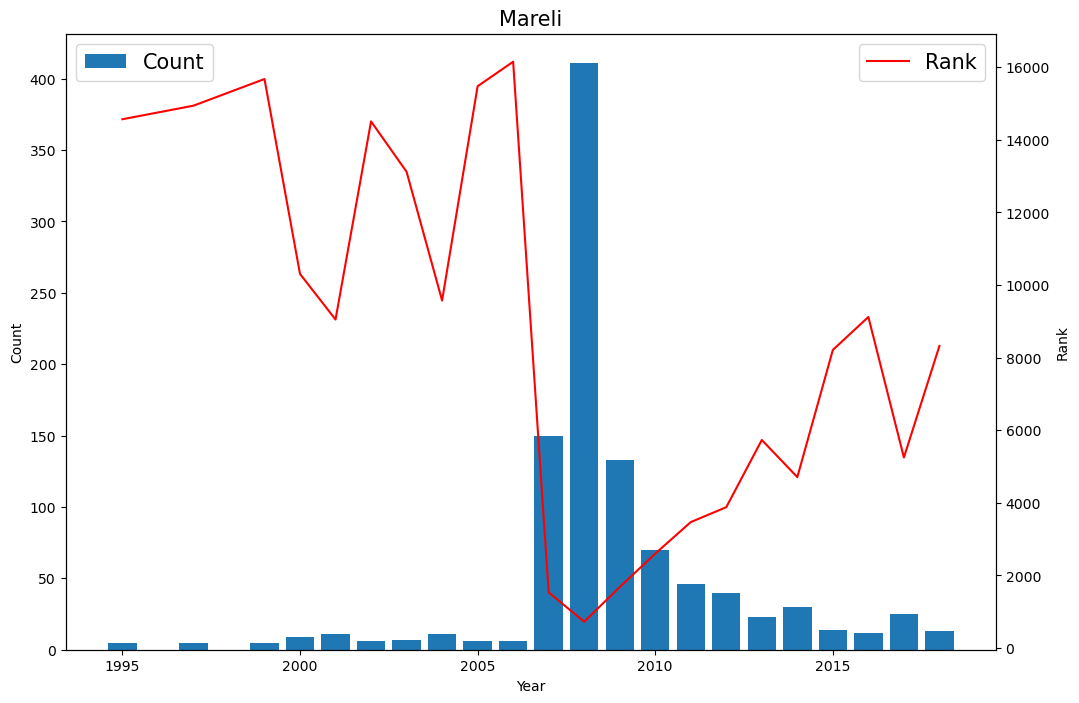

In [85]:
for n in l2:
    plot_name(name=n[0], gender=n[1], crit="Count")

# Most Popula Unisex Name 

In [86]:
df

,Year,Name,Gender,Count,Popularity,Rank,Pop_lag1,Pop_Diff
0,1880,Mary,F,7065,77642,1,NaN,NaN
1,1880,Anna,F,2604,28617,2,NaN,NaN
2,1880,Emma,F,2003,22012,3,NaN,NaN
3,1880,Elizabeth,F,1939,21309,4,NaN,NaN
4,1880,Minnie,F,1746,19188,5,NaN,NaN
...,...,...,...,...,...,...,...,...
1957041,2018,Zylas,M,5,3,13042,4,-1
1957042,2018,Zyran,M,5,3,13042,3,-0
1957043,2018,Zyrie,M,5,3,13042,3,0
1957044,2018,Zyron,M,5,3,13042,8,-5


In [87]:
df[df.Name == "Mary"].groupby(["Name", "Gender"], observed=True).Count.sum()

Name  Gender
Mary  F         4125675
      M           15165
Name: Count, dtype: int64

In [88]:
df.groupby(["Name", "Gender"], observed=True).Count.sum()

Name     Gender
Aaban    M         114
Aabha    F          35
Aabid    M          16
Aabidah  F           5
Aabir    M          10
                  ... 
Zyvion   M           5
Zyvon    M           7
Zyyanna  F           6
Zyyon    M           6
Zzyzx    M          10
Name: Count, Length: 109173, dtype: int64

In [89]:
df.groupby(["Name", "Gender"], observed=True).Count.sum().unstack()

Gender,F,M
Name,,
Aaban,NaN,114
Aabha,35,NaN
Aabid,NaN,16
Aabidah,5,NaN
Aabir,NaN,10
...,...,...
Zyvion,NaN,5
Zyvon,NaN,7
Zyyanna,6,NaN


In [90]:
unisex = df.groupby(["Name", "Gender"], observed=True).Count.sum().unstack()
unisex

Gender,F,M
Name,,
Aaban,NaN,114
Aabha,35,NaN
Aabid,NaN,16
Aabidah,5,NaN
Aabir,NaN,10
...,...,...
Zyvion,NaN,5
Zyvon,NaN,7
Zyyanna,6,NaN


In [91]:
unisex.dropna(inplace=True)
unisex

Gender,F,M
Name,,
Aaden,5,4828
Aadi,16,851
Aadyn,16,516
Aalijah,149,212
Aaliyah,87442,96
...,...,...
Zyion,168,918
Zyon,620,2638
Zyonn,5,40


Sort most populary Unisex names

1st Method

In [92]:
unisex.min(axis=1)

Name
Aaden       5
Aadi       16
Aadyn      16
Aalijah   149
Aaliyah    96
           ..
Zyion     168
Zyon      620
Zyonn       5
Zyree      16
Zyrie      16
Length: 10773, dtype: float64

In [93]:
unisex.min(axis=1).sort_values(ascending=False)

Name
Willie   146156
Jordan   131004
Leslie   112726
Taylor   110390
Jessie   110212
          ...  
Hany          5
Hao           5
Haram         5
Harjap        5
Aaden         5
Length: 10773, dtype: float64

In [94]:
unisex_names = unisex.min(axis=1).sort_values(ascending=False).index
unisex_names

Index(['Willie', 'Jordan', 'Leslie', 'Taylor', 'Jessie', 'Terry', 'Angel',
       'Riley', 'Jamie', 'Kelly',
       ...
       'Hanalei', 'Handy', 'Haniel', 'Hans', 'Hansel', 'Hany', 'Hao', 'Haram',
       'Harjap', 'Aaden'],
      dtype='object', name='Name', length=10773)

In [95]:
unisex.loc[unisex_names].head()

Gender,F,M
Name,,
Willie,146156,448946
Jordan,131004,374513
Leslie,267081,112726
Taylor,320446,110390
Jessie,167462,110212


2nd Method

In [100]:
unisex = unisex[unisex.min(axis=1) > 10000]
unisex

Gender,F,M
Name,,
Addison,121435,12895
Adrian,15258,237044
Alexis,338333,63604
Amari,14415,17932
Angel,95710,231800
...,...,...
Tommie,17415,34210
Tracy,250853,61223
Tyler,16585,587571


In [101]:
unisex_names2 = abs(unisex.F.div(unisex.M).sub(1)).sort_values().index
unisex_names2

Index(['Elisha', 'Quinn', 'Kerry', 'Blair', 'Kris', 'Robbie', 'Justice',
       'Riley', 'Emerson', 'Jackie',
       ...
       'Sandy', 'Stacy', 'Carmen', 'Shelby', 'Addison', 'Stacey', 'Courtney',
       'Jean', 'Ashley', 'Mary'],
      dtype='object', name='Name', length=116)

In [102]:
unisex.loc[unisex_names2].head()

Gender,F,M
Name,,
Elisha,13762,13595
Quinn,31670,32071
Kerry,48549,49646
Blair,14922,14527
Kris,13504,14055


# +++++++++ See some Hints below +++++++++++++

# ++++++++++++++++ Hints++++++++++++++++++++

__Hints for 5. and 6.__<br>
Use most_pop().

__Hints for 7.__


In [99]:
agg = df.groupby(...).agg(Total = (...), No_Year = (...), First_Year = (...), Last_Year = (...), Max_Count = (...))

TypeError: 'ellipsis' object is not callable

Add Best_Year separately with a udf (tricky...)

__Hints for 10.__<br>
Aggregate agg further.

__Hints for 12.__<br>
Treat Instances of Unisex Names (eg. (Marie, F) and (Marie, M)) as different Names.

__Hints for 13.__<br>
Use groupby() and transform()

__Hints for 14.__<br>
Use groupby() and apply(lambda x: x.rank(ascending = False))

__Hints for 17.__<br>
shift() might help.

__Hints for 18.__<br>
difference between "Popularity" and "Pop_lag1".

__Hints for 19.__<br>
use nlargest()